In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import pingouin as pg

In [2]:
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, to_hex
from matplotlib.ticker import FormatStrFormatter

In [3]:
from jupyter_utils import add_grey

In [4]:
import statsmodels.api as sm

In [5]:
sns.set_style("ticks")

In [6]:
# warnings.simplefilter("ignore")
warnings.filterwarnings('ignore', r'All-NaN (slice|axis) encountered')

In [7]:
PATH = '/Users/galina.ryazanskaya/Downloads/thesis?/code?/processed_values/'

In [8]:
PATH_FIG = '/Users/galina.ryazanskaya/Downloads/thesis?/figures/'

In [9]:
long_df_ru = pd.read_csv(PATH + 'long_ru_sz_dep.csv', index_col=0)

In [10]:
long_df_ru_ps_only = long_df_ru[long_df_ru['subset'] == 'psychosis_only']

In [11]:
long_df_ru_dep_only = long_df_ru[long_df_ru['subset'] == 'depression_only']

In [12]:
long_df_de = pd.read_csv(PATH + 'long_de.csv', index_col=0)

In [13]:
long_df = pd.concat([long_df_ru_ps_only, long_df_de])
long_df.tail()

,lang,subset,task,scale,performance_metric,metric_group,metric_name,median,mean,CI_low,...,corr_mean_sent_len_CI_low,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high
1627,de,NaN,sadness,sample_raw,r,graph,PE,-0.253781,-0.253540,-0.354410,...,0.146481,0.295637,0.484450,0.484197,0.429283,0.537478,0.406032,0.408511,0.362582,0.454813
1628,de,NaN,sadness,sample_raw,r,graph,degree_average,-0.212125,-0.214437,-0.332848,...,0.209155,0.374124,0.431843,0.432299,0.389736,0.480572,0.401243,0.403620,0.359008,0.445025
1629,de,NaN,sadness,sample_raw,r,graph,degree_std,-0.302485,-0.300454,-0.411071,...,0.296882,0.438948,0.461780,0.460888,0.416008,0.505992,0.457236,0.459037,0.417914,0.496821
1630,de,NaN,sadness,sample_raw,r,graph,number_of_edges,-0.454270,-0.443863,-0.525211,...,0.394044,0.508661,0.530958,0.530160,0.501695,0.558865,0.557838,0.559022,0.526002,0.589124
1631,de,NaN,sadness,sample_raw,r,graph,number_of_nodes,-0.451549,-0.442052,-0.519729,...,0.333328,0.445929,0.403811,0.400985,0.353971,0.452367,0.450036,0.449793,0.404327,0.495575


## Assign colors to metrics

fix metric colors - dict (color by group)  \
fix metric order

In [14]:
metric_groups = {group: long_df[long_df['metric_group'] == group]['metric_name'].unique().tolist() for group in long_df['metric_group'].unique()}

In [15]:
# {x: x.replace('_', ' ') for x in long_df['metric_name'].unique()}

In [16]:
name_map = {'bert_cgcoh': 'BERT cgcoh',
 'bert_gcoh': 'BERT gcoh',
 'bert_lcoh': 'BERT lcoh',
 'bert_pppl': 'BERT pppl',
 'bert_scoh': 'BERT scoh',
 'bert_sprob': 'BERT sprob',
 'glove_avg_cgcoh': 'GloVe mean cgcoh',
 'glove_avg_gcoh': 'GloVe mean gcoh',
 'glove_avg_lcoh': 'GloVe mean lcoh',
 'glove_avg_scoh': 'GloVe mean scoh',
 'glove_tf_cgcoh': 'GloVe tf cgcoh',
 'glove_tf_gcoh': 'GloVe tf gcoh',
 'glove_tf_lcoh': 'GloVe tf lcoh',
 'glove_tf_scoh': 'GloVe tf scoh',
 'w2v_avg_cgcoh': 'w2v mean cgcoh',
 'w2v_avg_gcoh': 'w2v mean gcoh',
 'w2v_avg_lcoh': 'w2v mean lcoh',
 'w2v_avg_scoh': 'w2v mean scoh',
 'w2v_tf_cgcoh': 'w2v tf cgcoh',
 'w2v_tf_gcoh': 'w2v tf gcoh',
 'w2v_tf_lcoh': 'w2v tf lcoh',
 'w2v_tf_scoh': 'w2v tf scoh',
 'L1': 'loops of size 1',
 'L2': 'loops of size 2',
 'L3': 'loops of size 3',
 'LCC': 'LCC',
 'LSC': 'LSC',
 'PE': 'parallel edges',
 'degree_average': 'degree mean',
 'degree_std': 'degree std',
 'number_of_edges': 'number of edges',
 'number_of_nodes': 'number of nodes',
 'LTR': 'LTR',
 'MALTR': 'MALTR',
 'n_words': 'word count',
 'ADJ': 'POS rate: ADJ',
 'ADV': 'POS rate: ADV',
 'AUX': 'POS rate: AUX',
 'CCONJ': 'POS rate: CCONJ',
 'DET': 'POS rate: DET',
 'NOUN': 'POS rate: NOUN',
 'PART': 'POS rate: PART',
 'PRON': 'POS rate: PRON',
 'PROPN': 'POS rate: PROPN',
 'SCONJ': 'POS rate: SCONJ',
 'VERB': 'POS rate: VERB',
 'max_sent_len': 'max sent len',
 'mean_sent_len': 'mean sent len',
 'min_sent_len': 'min sent len',
 'n_sents': 'sent count',
 'std_sent_len': 'std sent len'}

In [17]:
len('Loops of size 1')

15

In [18]:
print(*[(x, name_map[x], len(name_map[x])) for x in long_df['metric_name'].unique()], sep='\n')

('bert_cgcoh', 'BERT cgcoh', 10)
('bert_gcoh', 'BERT gcoh', 9)
('bert_lcoh', 'BERT lcoh', 9)
('bert_pppl', 'BERT pppl', 9)
('bert_scoh', 'BERT scoh', 9)
('bert_sprob', 'BERT sprob', 10)
('glove_avg_cgcoh', 'GloVe mean cgcoh', 16)
('glove_avg_gcoh', 'GloVe mean gcoh', 15)
('glove_avg_lcoh', 'GloVe mean lcoh', 15)
('glove_avg_scoh', 'GloVe mean scoh', 15)
('glove_tf_cgcoh', 'GloVe tf cgcoh', 14)
('glove_tf_gcoh', 'GloVe tf gcoh', 13)
('glove_tf_lcoh', 'GloVe tf lcoh', 13)
('glove_tf_scoh', 'GloVe tf scoh', 13)
('w2v_avg_cgcoh', 'w2v mean cgcoh', 14)
('w2v_avg_gcoh', 'w2v mean gcoh', 13)
('w2v_avg_lcoh', 'w2v mean lcoh', 13)
('w2v_avg_scoh', 'w2v mean scoh', 13)
('w2v_tf_cgcoh', 'w2v tf cgcoh', 12)
('w2v_tf_gcoh', 'w2v tf gcoh', 11)
('w2v_tf_lcoh', 'w2v tf lcoh', 11)
('w2v_tf_scoh', 'w2v tf scoh', 11)
('L1', 'loops of size 1', 15)
('L2', 'loops of size 2', 15)
('L3', 'loops of size 3', 15)
('LCC', 'LCC', 3)
('LSC', 'LSC', 3)
('PE', 'parallel edges', 14)
('degree_average', 'degree mean', 1

In [19]:
LM_groups_metrics = {}
LM_groups_models = {}
for metric_name in metric_groups['LM']:
    model, metric = metric_name.rsplit('_', 1)
    LM_groups_metrics.setdefault(metric, []).append(metric_name)
    LM_groups_models.setdefault(model, []).append(metric_name)

In [20]:
group_to_color = {'graph': '#AD2070', #"#fbacb9", # '#ad017e', 
                  'lexical': '#A29CE4', 
                  'syntactic': '#FD9341', 
                  'LM': "#4D7E80"}
group_to_palette = {'graph': 'RdPu', 'lexical': 'Purples', 'syntactic': 'YlOrRd'}

In [21]:
model_to_color = {'bert': '#3b6a2a', 'glove_avg': '#1d5b5d', 'glove_tf': '#274754', 'w2v_avg': '#0c2c41', 'w2v_tf': '#1d3658'}

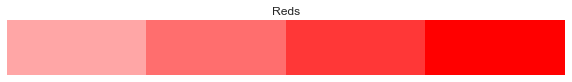

In [22]:
def sample_categorical_palette(color_name, size, cmap=None, low=0.35):
    """
    Samples evenly from a continuous colormap ranging from light-shade to a full color,
    to create a categorical palette.
    
    Parameters:
    - color_name (str): Name of the target color (e.g., "blue", "red", "#ff5733").
    - size (int): Number of discrete colors in the resulting categorical palette.
    
    Returns:
    - list: A list of RGB tuples representing the categorical palette.
    """
    # Get the colormap
    if not cmap:
        cmap = LinearSegmentedColormap.from_list("custom_colormap", ["white", color_name])
    
    # Sample evenly spaced values between low and 1
    colors = [cmap(i) for i in np.linspace(low, 1, size)]
    
    return colors

# Visualize the sampled palette
def visualise_palette(palette, title):
    plt.figure(figsize=(10, 1))
    plt.imshow([palette], aspect="auto")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Example usage:
categorical_palette = sample_categorical_palette('red', 4)
visualise_palette(categorical_palette, 'Reds')

In [23]:
metric_to_color = {}
for group in metric_groups:
    if group == 'LM':
        for model in LM_groups_models:
            tgt_color = model_to_color[model]
            tgt_len = len(LM_groups_models[model])
            palette = sample_categorical_palette(tgt_color, tgt_len)
            # visualise_palette(palette, model)
            for i, metric in enumerate(LM_groups_models[model]):
                metric_to_color[metric] = to_hex(palette[i])
    else:
        tgt_plt = group_to_palette[group]
        tgt_len = len(metric_groups[group])
        low = 0.3 if group != 'lexical' else 0.5
        palette = sample_categorical_palette('', tgt_len, cmap=plt.get_cmap(tgt_plt), low=low)
        # visualise_palette(palette, group)
        for i, metric in enumerate(metric_groups[group]):
            metric_to_color[metric] = to_hex(palette[i])


## Assess task dificulty


for each task - count metrics that perform on it

In [24]:
def CI_does_not_intersect_zero(line):
    return line['CI_low'] * line['CI_high'] > 0

In [25]:
# long_df[~long_df.apply(CI_does_not_intersect_zero, axis=1)]

In [26]:
def perfrom_above_treshold(line, r=0.3, t=0.2, ps_r=0.09):
    if not CI_does_not_intersect_zero(line):
        return False
    elif line['performance_metric'] == 't':
        return True
    elif line['performance_metric'] == 'r' and abs(line['median']) > r:
        return True
    elif line['performance_metric'] == 'ps_r' and abs(line['median']) > ps_r:
        return True
    return False

In [27]:
control_cols = ['mean_sent_len', 'n_sents', 'n_words']

In [28]:
def perfrom_above_baselines(df, lang, metric_name):
    data = df[df['lang'] == lang]
    base_perf = False
    for task in data['task'].unique():
        for outcome in ['t', 'r', 'ps_r']:
            for scale in df['scale'].unique():
                t_data = data[(data['task'] == task) & (data['performance_metric'] == outcome) & (data['scale'] == scale)]
                if len(t_data) == 0:
                    continue
                max_baseline_value = 0
                for col in control_cols:
                    base_val = t_data[t_data['metric_name'] == col]['median'].abs().values[0]
#                     print(base_val)
                    max_baseline_value = max(max_baseline_value, base_val)
                outcome_val = t_data[t_data['metric_name'] == metric_name]['median'].abs().values[0]
                if outcome_val > max_baseline_value:
                    base_perf = True
    return base_perf and perfrom_above_treshold_any(df, lang, metric_name)

In [29]:
def perfrom_above_treshold_any(df, lang, metric_name):
    data = df[(df['metric_name'] == metric_name) & (df['lang'] == lang)]
    return data.apply(perfrom_above_treshold, axis=1).any()

In [30]:
# for metric in metric_to_color:
#     for lang in ["de", "ru"]:
#         print(metric, lang, perfrom_above_baselines(long_df, lang, metric)) 

In [31]:
# long_df['task'].value_counts()

In [32]:
# long_df[long_df[['lang', 'task', 'scale', 'performance_metric', 'metric_group', 'metric_name']].duplicated(keep=False)]

In [33]:
long_df[long_df.apply(perfrom_above_treshold, axis=1)]['task'].value_counts()

task
present      167
adventure    133
chair        131
anger        126
sportsman    112
fear         102
sadness       89
happiness     42
Name: count, dtype: int64

In [34]:
long_df[long_df.apply(perfrom_above_treshold, axis=1) & (long_df["scale"]== "panss_total")]['task'].value_counts()

task
present      15
anger        14
fear         14
adventure    13
chair        11
sadness       9
sportsman     7
happiness     1
Name: count, dtype: int64

In [35]:
best_task = {"ru": "present", "de": "anger"}

## Plot all metrics on the best task for each language

for the best task, for each langugae 4 x 2 panels - each metric group vs t-test performance and correlation with panss total - three baselines 

In [36]:
def plot_horisontal_ci_ax(df, ax, palette=None, key='median', 
                          xlabel='Mean Value with Confidence Interval', add_zero=True, markers=None):
    # Add custom error bars based on the confidence intervals
    for i, row in df.iterrows():
        if not palette:
            color = 'skyblue'
        elif isinstance(palette, list):
            color = palette[i]
        elif isinstance(palette, dict):
            color = palette.get(row['metric_name'], 'skyblue')
        marker = 'o' if markers is None else markers[row['metric_name']]
        
        ax.errorbar(row[key], name_map[row['metric_name']], 
                     xerr=[[abs(row[key] - row['CI_low'])], [abs(row['CI_high'] - row[key])]], 
                     color=color, capsize=0, elinewidth=2, marker=marker)
#         ax.scatter(row[key], row['metric_name'], marker=marker, color = color)

    # Add labels and title
    if xlabel:
        ax.set_xlabel(xlabel)
    if add_zero:
        ax.axvline(0, color="darkgrey")

In [37]:
def add_baseline_lines(ax, value, add_neg=True, color=None, alpha=1):
    color = color or "lightblue"
    ax.axvline(value, linestyle=':', color=color, alpha=alpha)
    if add_neg:
        ax.axvline(-value, linestyle=':', color=color, alpha=alpha)

In [38]:
def get_data(df, lang, task, metric_group=None, scale='panss_total', performance_metric='r'):
    if not metric_group:
        return df[(df["lang"] == lang) & (df["task"] == task) & (df["scale"] == scale) & (df["performance_metric"] == performance_metric)]
    else:
        return df[(df["lang"] == lang) & (df["task"] == task) & 
                  (df["scale"] == scale) & (df["metric_group"] == metric_group) & (df["performance_metric"] == performance_metric)]

In [39]:
def add_control_lines(ax, df, lang, task, scale='panss_total', performance_metric='r', control_cols=control_cols, alpha=1, key="median"):
    for control_col in control_cols:
        cdata = get_data(df, lang, task, scale=scale, performance_metric=performance_metric)
        if not cdata[cdata["metric_name"] == control_col][key].values:
            print(lang, task, scale, control_col, performance_metric)
        control_median = cdata[cdata["metric_name"] == control_col][key].values[0]
        control_color = metric_to_color[control_col]
        add_baseline_lines(ax, control_median, color=control_color, alpha=alpha)

In [40]:
# ex = get_data(long_df, "ru", "present", "syntactic")
# fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
# ax = axes

# plot_horisontal_ci_ax(ex, ax, palette=metric_to_color, xlabel=None)
# for control_col in control_cols:
#     cdata = get_data(long_df, "ru", "present")
#     control_median = cdata[cdata["metric_name"] == control_col]["median"].values[0]
#     control_color = metric_to_color[control_col]
#     add_baseline_lines(ax, control_median, color=control_color)
# fig.suptitle('Syntactic metrics on russian present task, correlation with PANSS total')

# add_grey(ax)

# # Show the plot
# plt.tight_layout()
# plt.show()

In [41]:
dpi = 300

In [42]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"Correlation with PANSS total across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_panss_total_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

In [43]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'de'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"Correlation with PANSS total across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_panss_total_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

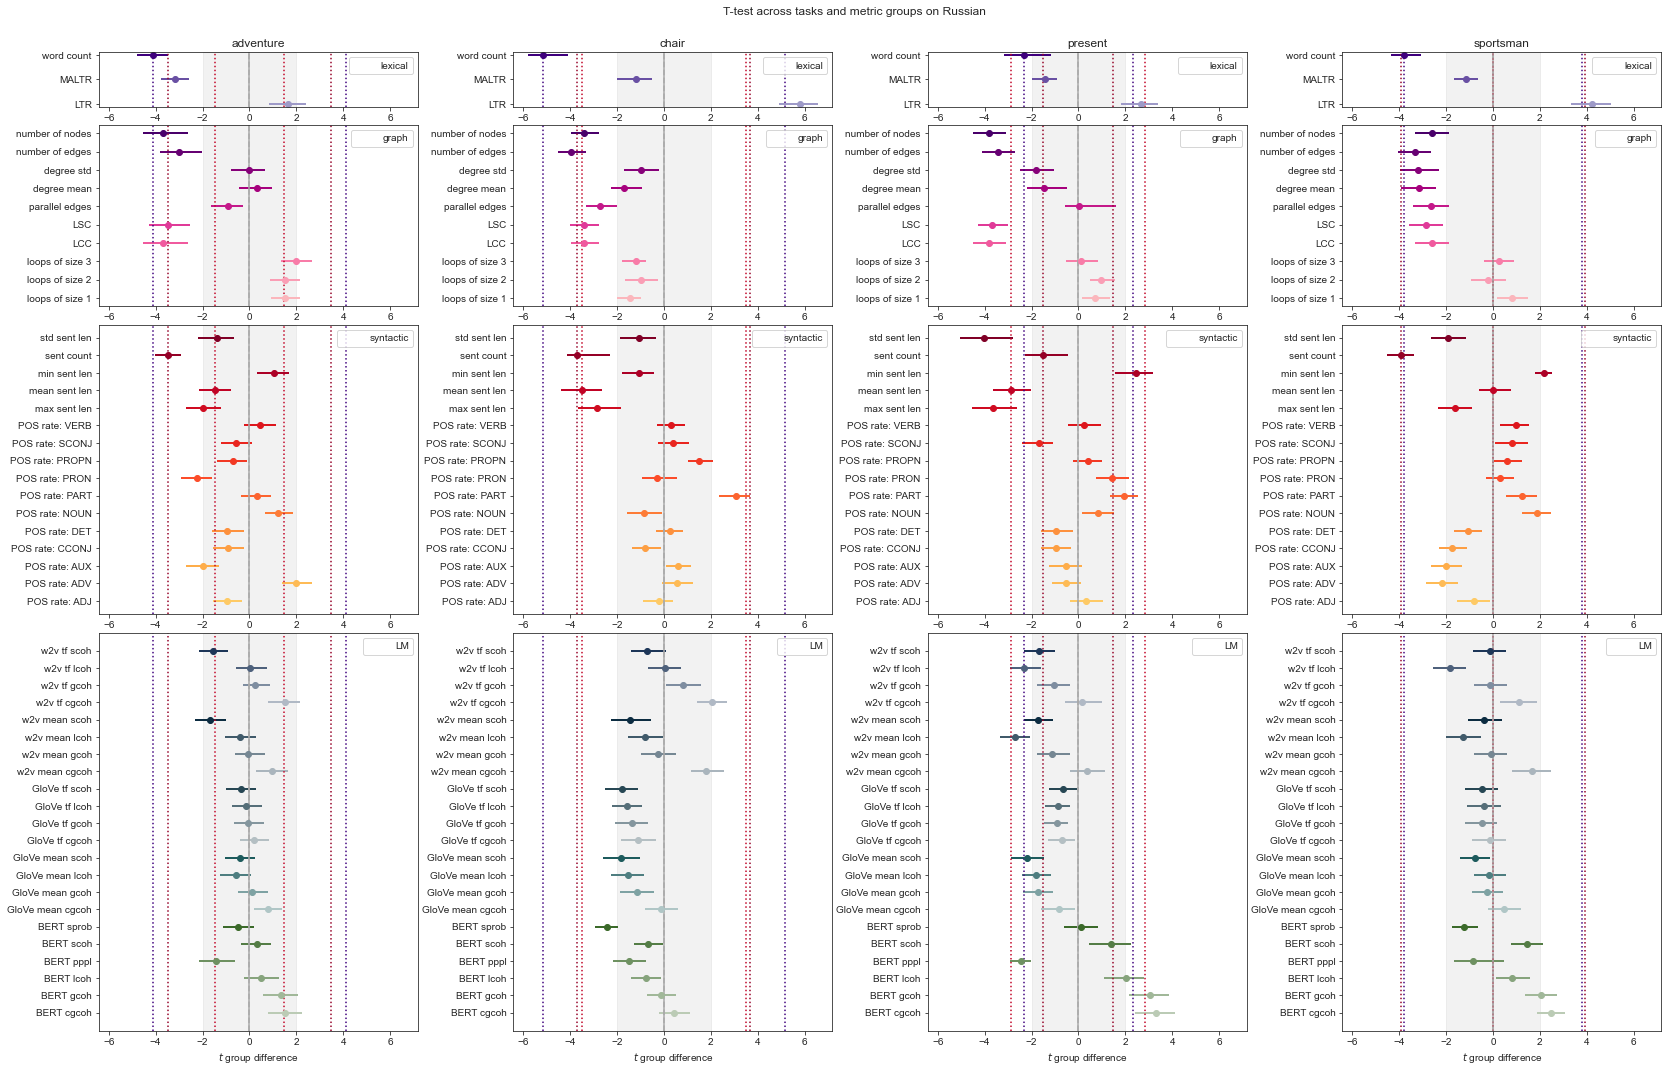

In [44]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

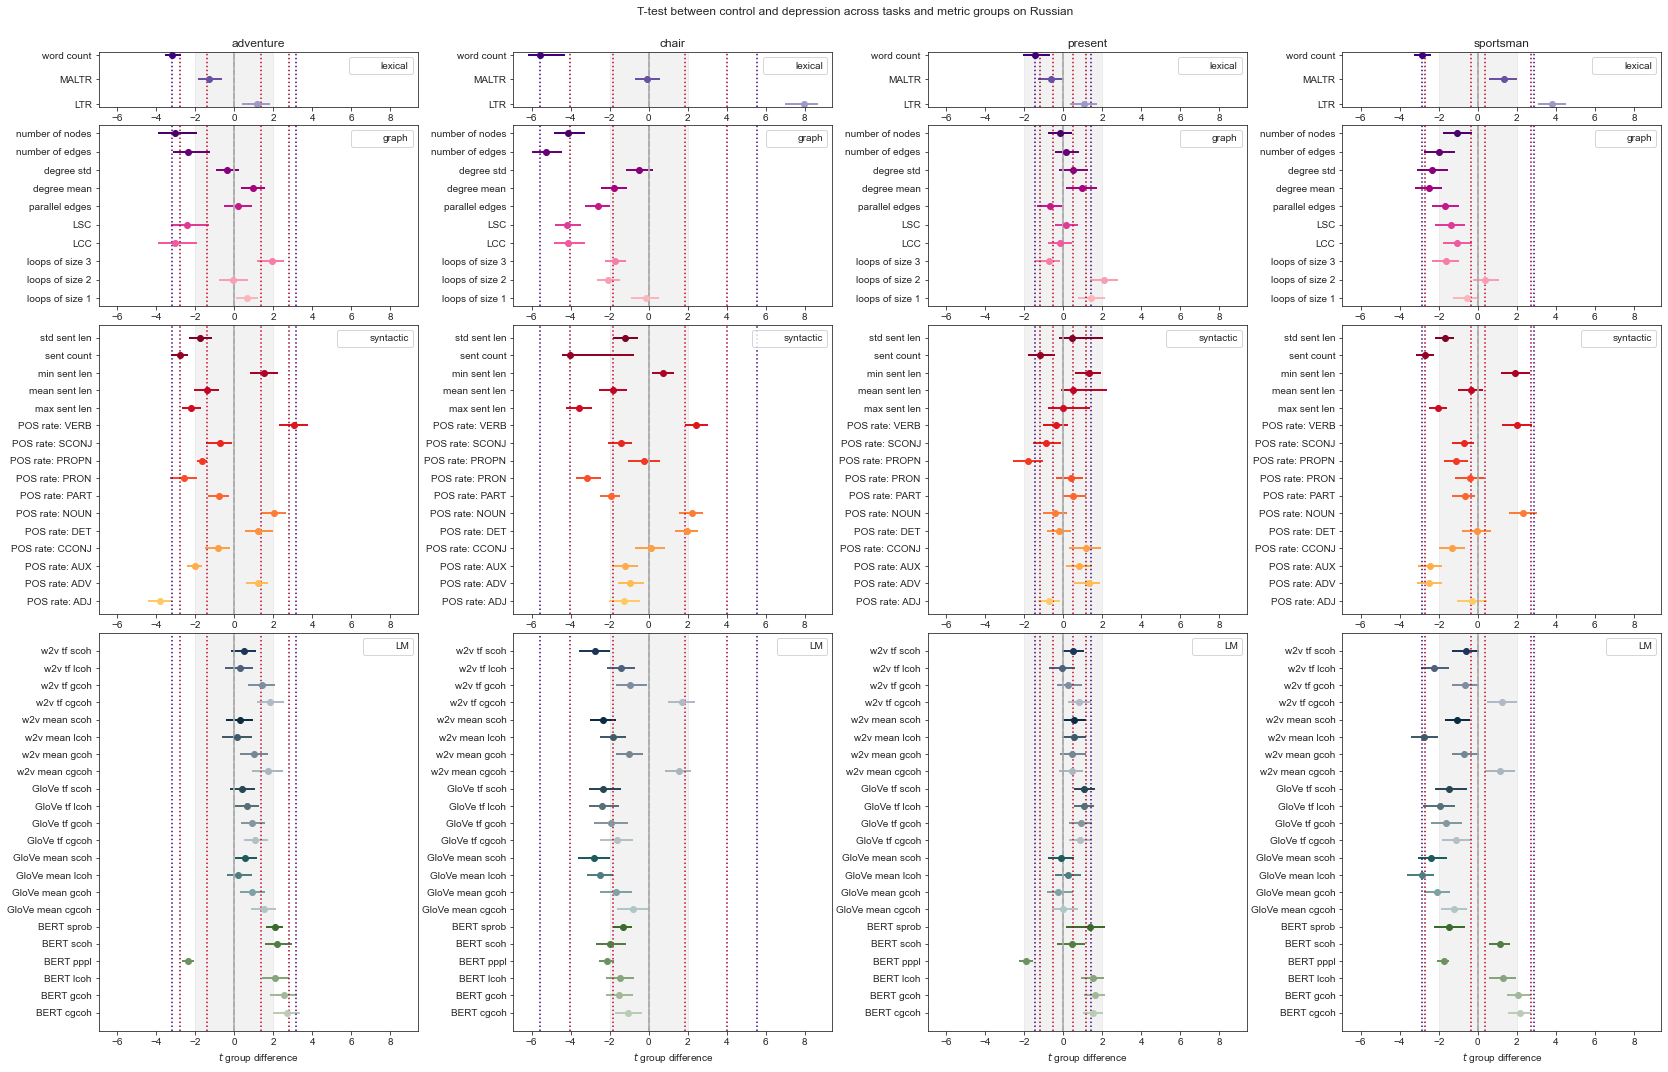

In [45]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff_dep', performance_metric='t_dep')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff_dep', performance_metric='t_dep')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test between control and depression across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_dep_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

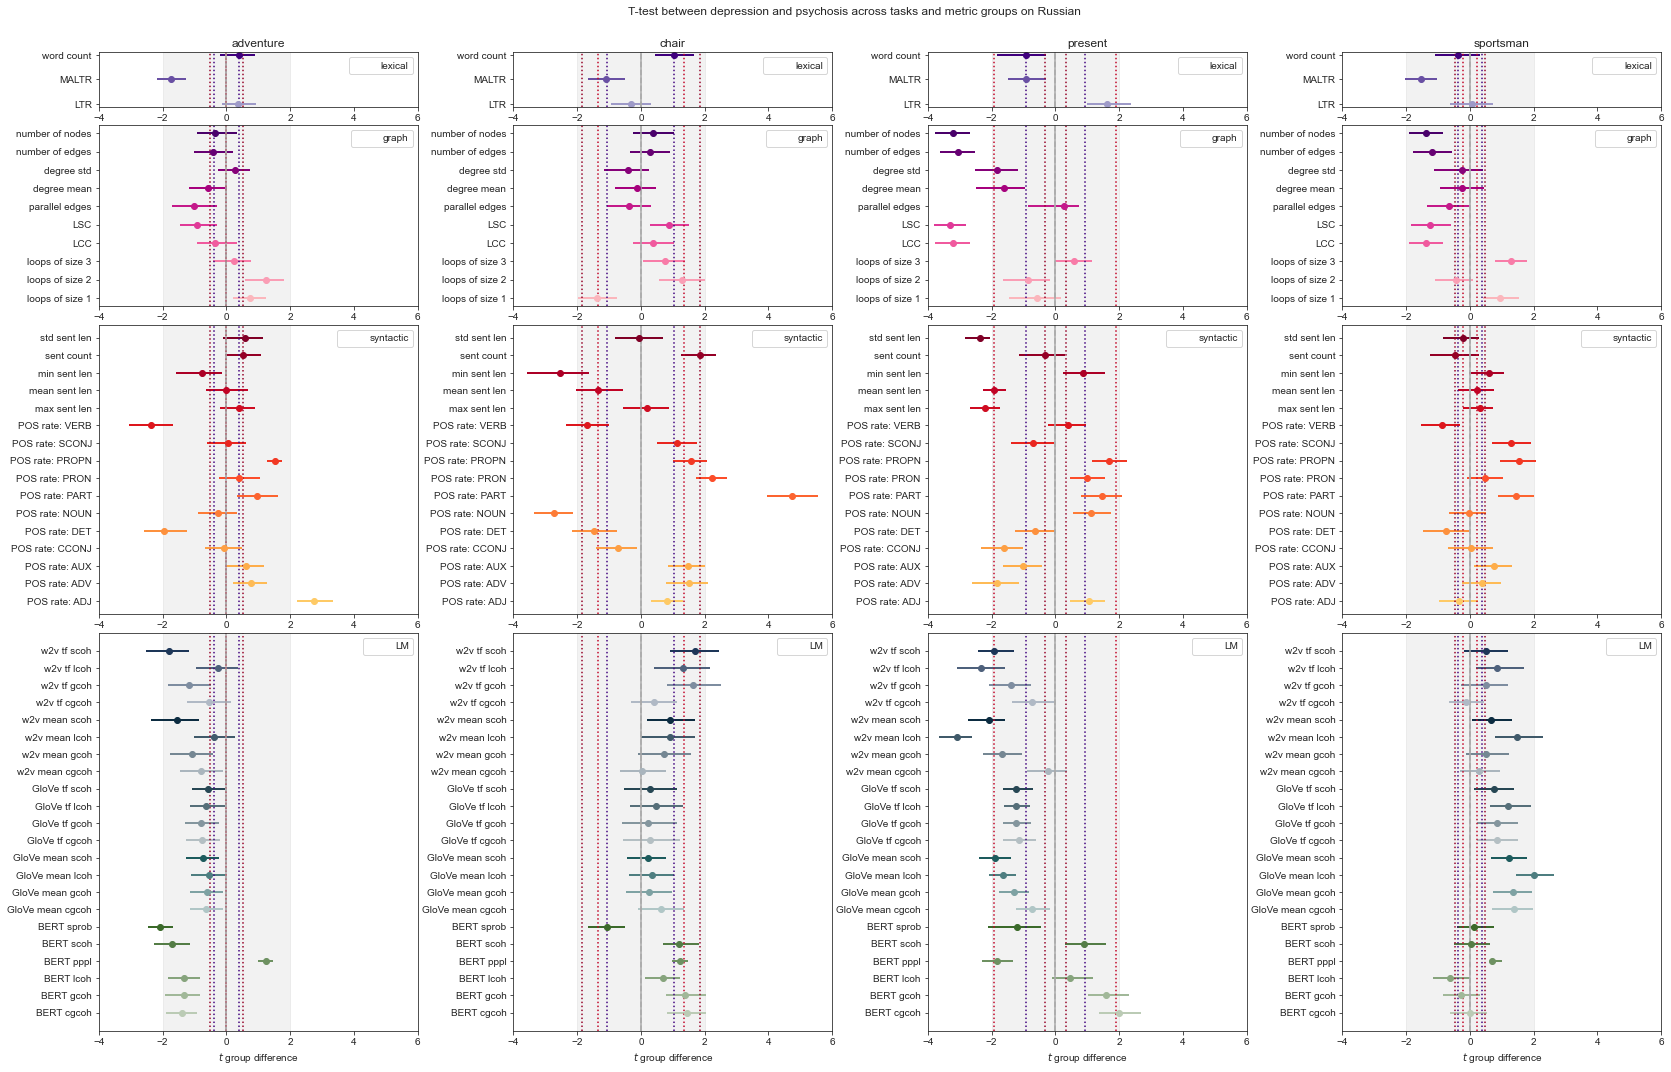

In [46]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff_sz_dep', performance_metric='t_sz_dep')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff_sz_dep', performance_metric='t_sz_dep')

        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
            if j == 0:
                ax.set_xlim(-4, 6)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)
        add_grey(ax, r=2)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test between depression and psychosis across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_sz_dep_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

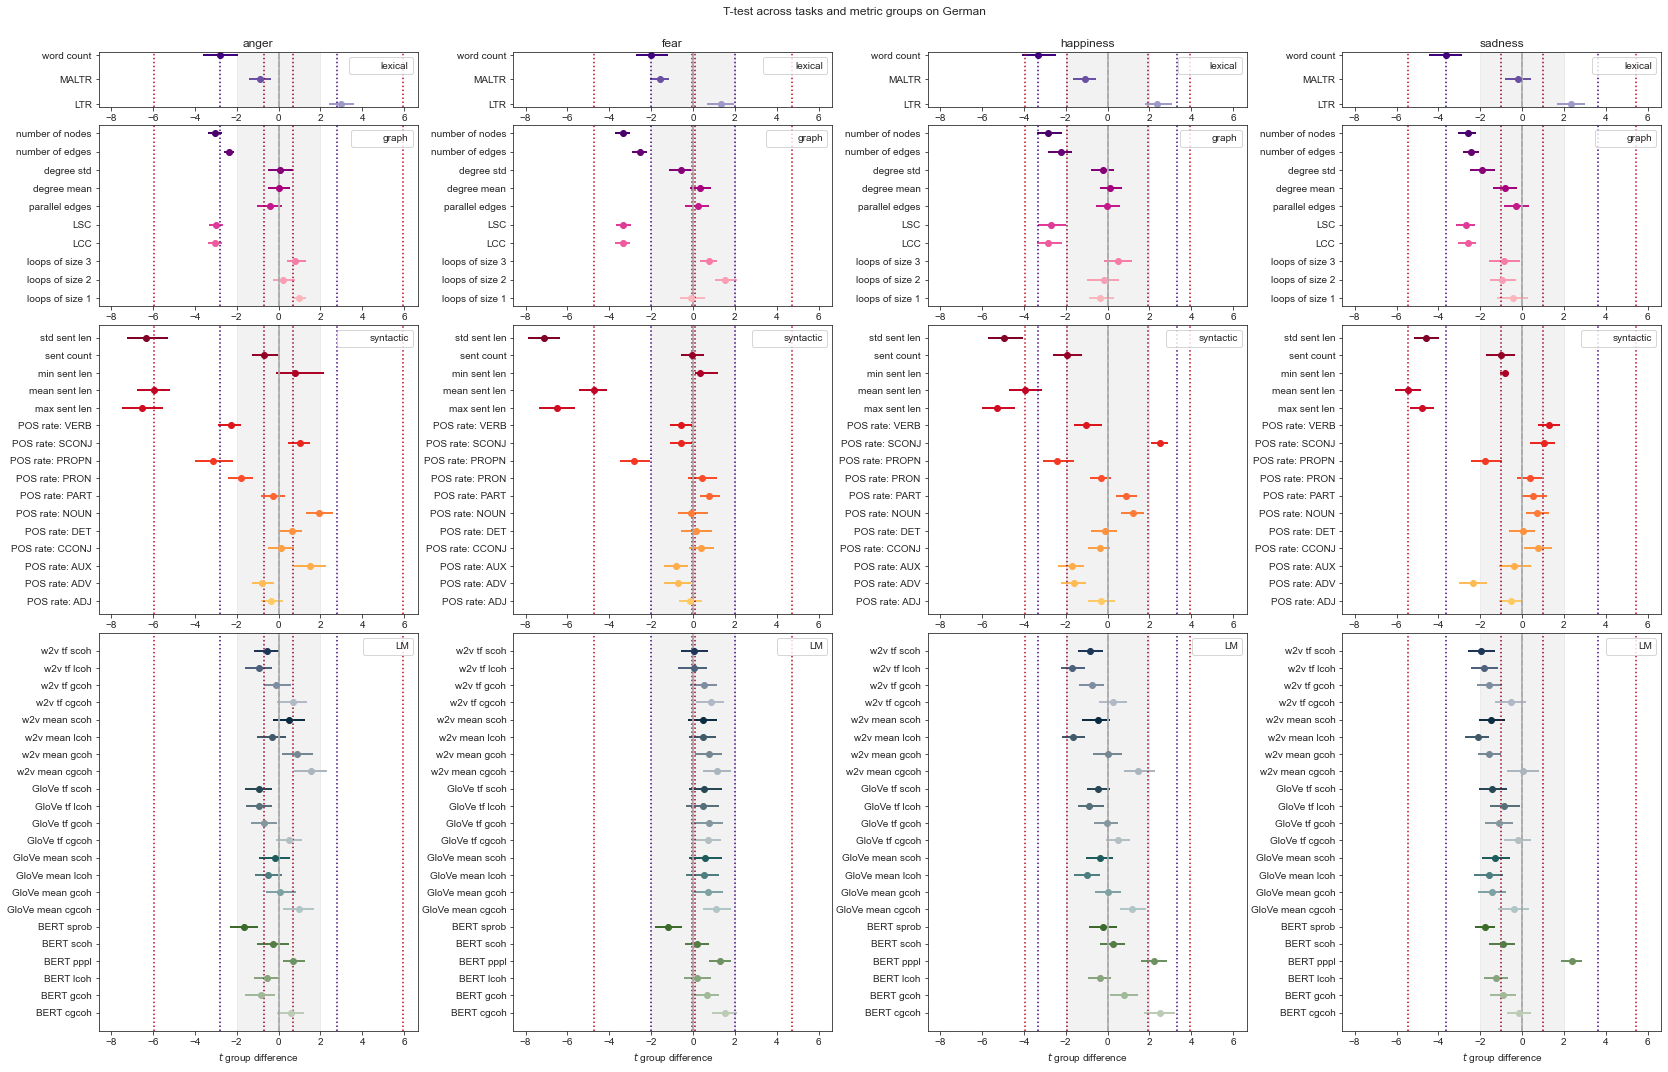

In [47]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'de'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

In [48]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        task = best_task[lang]
        data = get_data(long_df, lang, task, metric_group)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Correlation with PANSS total on the best task across metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}panss_total_best_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

In [49]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        task = best_task[lang]
        data = get_data(long_df, lang, task, metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang, task, scale='group_diff', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("T-test on the best task across metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}t-test_best_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

In [50]:
def mean_task_performance(df, metric_name, lang, scale, key='median', abs_=True):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['scale'] == scale)][key]
    if abs_:
        data = data.abs()
    return np.nanmean(data)

In [51]:
def SE_low_high_task_performance(df, metric_name, lang, scale, key='median', abs_=True):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['scale'] == scale)][key]
    if abs_:
        data = data.abs()
    se = np.std(data) / np.sqrt(len(data))
    return np.nanmean(data) - se,  np.nanmean(data) + se

In [52]:
def mean_CI_low_high_task_performance(df, metric_name, lang, scale, key='median', abs_=True):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['scale'] == scale)]
    if abs_:
        data = data.abs()
    CI_low, CI_high = np.nanmean(data['CI_low']), np.nanmean(data['CI_high'])
    return CI_low, CI_high

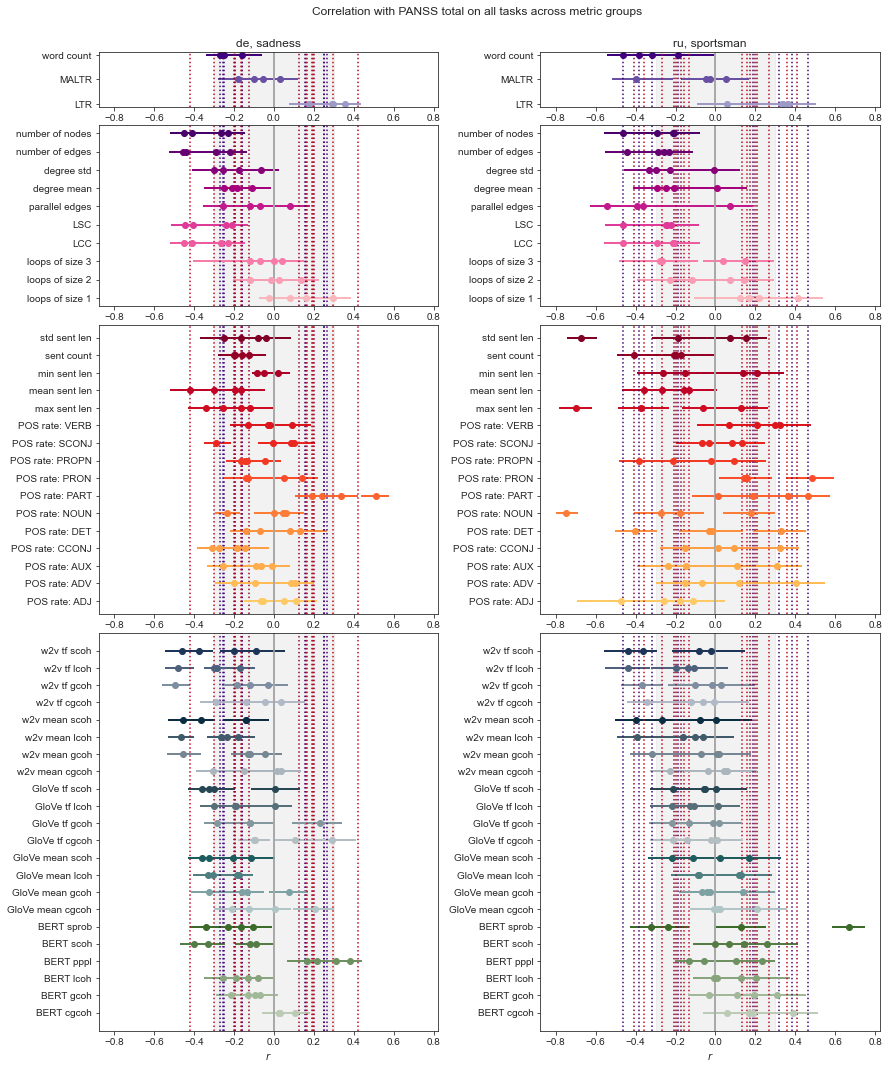

In [53]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        for task in long_df[long_df["lang"] == lang]["task"].unique():
            data = get_data(long_df, lang, task, metric_group)
            plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
            add_control_lines(ax, long_df, lang, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"{lang}, {task}")
        if i == 3:
            ax.set_xlabel("$r$")

fig.suptitle("Correlation with PANSS total on all tasks across metric groups", y=0.915);
plt.show()

plt.savefig(f'{PATH_FIG}panss_total_all_tasks_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
plt.close()

In [54]:
mean_data = []
for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        for scale in ['panss_total', 'panss_neg', 'group_diff', "group_diff_dep", "group_diff_sz_dep"]:
            perfromance_metric = long_df[long_df['scale'] == scale]['performance_metric'].unique()[0]
            metric_group = long_df[long_df['metric_name'] == metric_name]["metric_group"].values[0]
            mean = mean_task_performance(long_df, metric_name, lang, scale, abs_=False)
            mean_SE_low, mean_SE_high = SE_low_high_task_performance(long_df, metric_name, lang, scale, abs_=False)
            mean_CI_low, mean_CI_high = mean_CI_low_high_task_performance(long_df, metric_name, lang, scale, abs_=False)
            line = (lang, 'mean', scale, perfromance_metric, 
                              metric_name, metric_group, mean, 
                              mean_CI_low, mean_CI_high, mean_SE_low, mean_SE_high)
            for col in control_cols:
                mean_corr_control = mean_task_performance(long_df, metric_name, lang, scale, key=f'corr_{col}_median', abs_=False)
                mean_corr_control_abs = mean_task_performance(long_df, metric_name, lang, scale, key=f'corr_{col}_median', abs_=True)
                line += (mean_corr_control, mean_corr_control_abs)
            mean_data.append(line)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/892069397.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(data)
/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/3846410773.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(data) - se,  np.nanmean(data) + se


In [55]:
task_mean_df = pd.DataFrame(mean_data, columns=['lang', 'task', 'scale', 'performance_metric', 
                                                'metric_name', 'metric_group', 'median', 
                                                'CI_low', 'CI_high', 'SE_low', 'SE_high',
                                                'corr_mean_sent_len_median', 'corr_mean_sent_len_median_abs',
                                                'corr_n_sents_median', 'corr_n_sents_median_abs',
                                                'corr_n_words_median', 'corr_n_words_median_abs'])

In [56]:
mean_data_dep = []
lang_ = 'ru'
for metric_name in metric_to_color:
    for scale in ['panss_total', 'panss_neg', 'group_diff', "group_diff_dep", "group_diff_sz_dep"]:
        perfromance_metric = long_df_ru_dep_only[long_df_ru_dep_only['scale'] == scale]['performance_metric'].unique()[0]
        metric_group = long_df_ru_dep_only[long_df_ru_dep_only['metric_name'] == metric_name]["metric_group"].values[0]
        mean = mean_task_performance(long_df_ru_dep_only, metric_name, lang_, scale, abs_=False)
        mean_SE_low, mean_SE_high = SE_low_high_task_performance(long_df_ru_dep_only, metric_name, lang_, scale, abs_=False)
        mean_CI_low, mean_CI_high = mean_CI_low_high_task_performance(long_df_ru_dep_only, metric_name, lang_, scale, abs_=False)
        line = (lang_, 'mean', scale, perfromance_metric,
                          metric_name, metric_group, mean,
                          mean_CI_low, mean_CI_high, mean_SE_low, mean_SE_high)
        for col in control_cols:
            mean_corr_control = mean_task_performance(long_df_ru_dep_only, metric_name, lang_, scale, key=f'corr_{col}_median', abs_=False)
            mean_corr_control_abs = mean_task_performance(long_df_ru_dep_only, metric_name, lang_, scale, key=f'corr_{col}_median', abs_=True)
            line += (mean_corr_control, mean_corr_control_abs)
        mean_data_dep.append(line)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/892069397.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(data)


In [57]:
task_mean_dep_df = pd.DataFrame(mean_data_dep, columns=['lang', 'task', 'scale', 'performance_metric',
                                                'metric_name', 'metric_group', 'median',
                                                'CI_low', 'CI_high', 'SE_low', 'SE_high',
                                                'corr_mean_sent_len_median', 'corr_mean_sent_len_median_abs',
                                                'corr_n_sents_median', 'corr_n_sents_median_abs',
                                                'corr_n_words_median', 'corr_n_words_median_abs'])

In [58]:
def max_abs_baseline(df, lang, task, scale="panss_total", baselines=["n_sents", "n_words", "mean_sent_len"], value="median"):
    vals = df[(df["lang"] == lang) & (df["task"] == task) & (df["scale"] == scale) &
              df["metric_name"].isin(["n_sents", "n_words", "mean_sent_len"])][value]
    return max(abs(vals))

In [59]:
def outperform_best_baseline(df, lang, task, scale="panss_total", value="median"):
    best_baseline = max_abs_baseline(df, lang, task, scale=scale, value=value)
    df_slice = df[(df["lang"] == lang) & (df["task"] == task) & (df["scale"] == scale)
                 & (abs(df[value]) > best_baseline)]
    return df_slice["metric_name"]

In [60]:
best_de = outperform_best_baseline(task_mean_df, "de", "mean").to_list()
best_de

['w2v_avg_lcoh',
 'w2v_avg_scoh',
 'w2v_tf_lcoh',
 'w2v_tf_scoh',
 'LCC',
 'LSC',
 'number_of_edges',
 'number_of_nodes',
 'LTR',
 'PART']

In [61]:
best_ru = outperform_best_baseline(task_mean_df, "ru", "mean").to_list()
best_ru

[]

In [62]:
# fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
# plt.subplots_adjust(hspace=0.08, wspace=0.31)
# lang_ = 'ru'
# for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
#     for j, group_df in enumerate([task_mean_df, task_mean_dep_df]):
#         ax = axes[i, j]
#         data = get_data(group_df, lang_, 'mean', metric_group, scale='panss_neg')
#         high_performers = outperform_best_baseline(group_df, lang_, 'mean', scale='panss_neg').to_list()
#         markers = {metric_name: 'd' if metric_name in high_performers else '.'
#                    for metric_name in data['metric_name']}
#         # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
#         plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
#         add_control_lines(ax, group_df, lang_, 'mean', scale='panss_neg')
#         add_grey(ax, r=max_abs_baseline(group_df, lang_, 'mean', scale='panss_neg'))
#         ax.xaxis.set_tick_params(labelbottom=True)
#         if i == 0:
#             ax.set_title(f"psychosis" if j == 0 else "depression")
#         if i == 3:
#             ax.set_xlabel("$r$ negative symptom severity correlation (PANSS negative score)")
#         ax.plot([], [], ' ', label=metric_group)
#         ax.legend(loc=1)
#
# fig.suptitle("Correlation with PANSS negative averaged across tasks for all metric groups on psychosis vs depression groups", y=0.915);
# # plt.savefig(f'{PATH_FIG}panss_total_mean_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
# # plt.show()

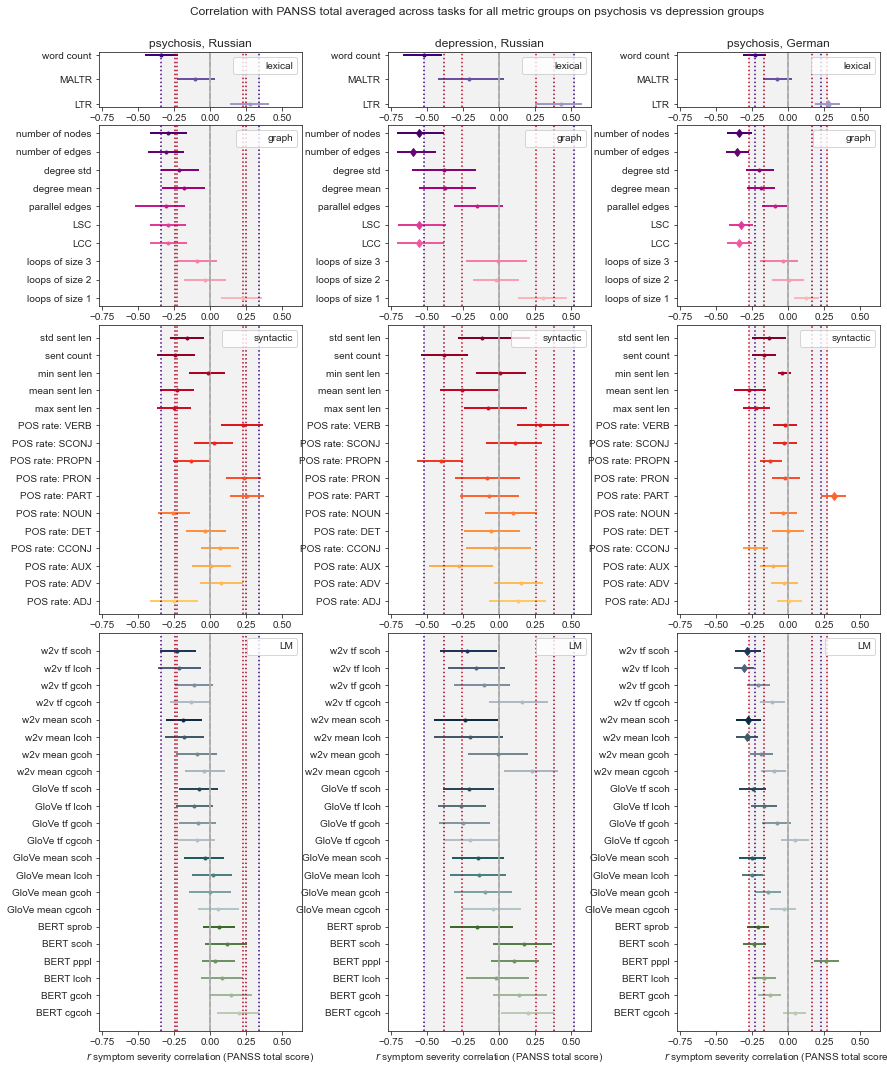

In [63]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.42)
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, group_df in enumerate([task_mean_df, task_mean_dep_df, task_mean_df[task_mean_df['lang'] == 'de']]):
        ax = axes[i, j]
        lang_ = 'ru' if j <= 1 else 'de'
        data = get_data(group_df, lang_, 'mean', metric_group)
        high_performers = outperform_best_baseline(group_df, lang_, 'mean').to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.'
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, group_df, lang_, 'mean')
        add_grey(ax, r=max_abs_baseline(group_df, lang_, 'mean'))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(['psychosis, Russian', 'depression, Russian', 'psychosis, German'][j])
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Correlation with PANSS total averaged across tasks for all metric groups on psychosis vs depression groups", y=0.915);
plt.savefig(f'{PATH_FIG}panss_total_mean_task_all_metrics_across_languages_dep_vs_sz.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

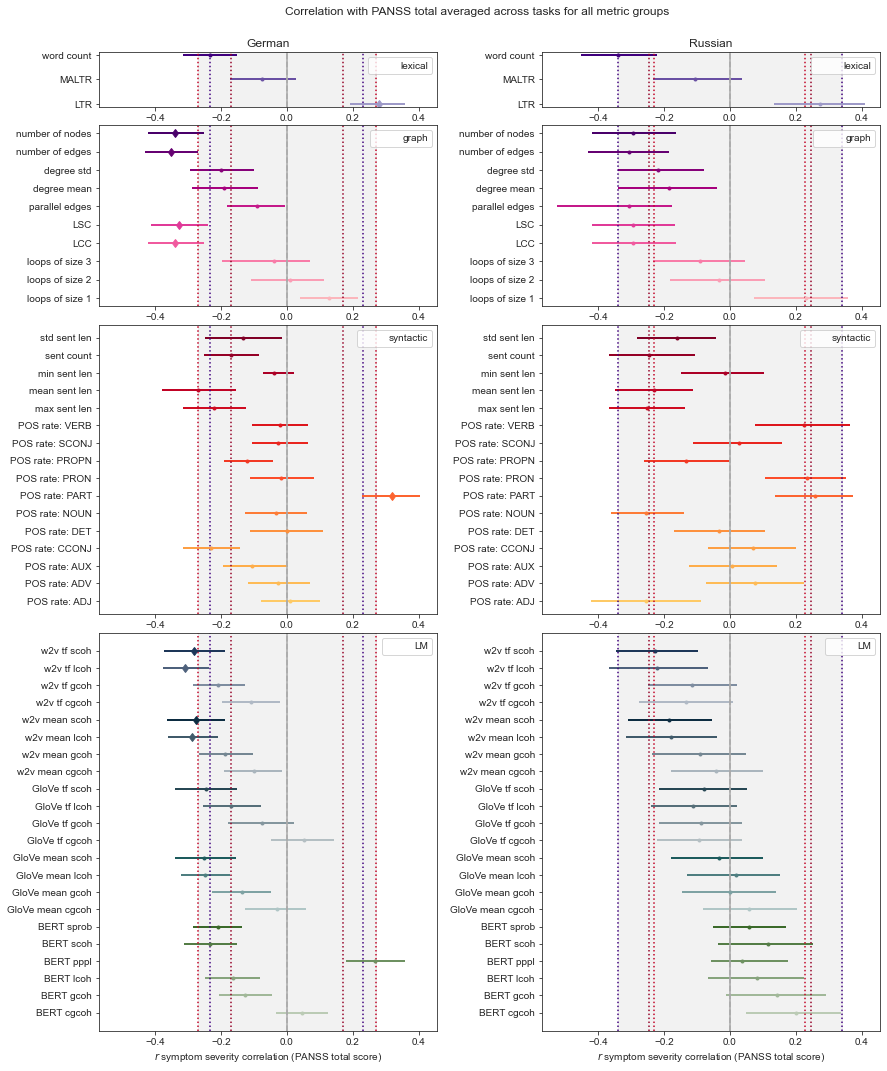

In [64]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.31)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group)
        high_performers = outperform_best_baseline(task_mean_df, lang, 'mean').to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.' 
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, task_mean_df, lang, 'mean')
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean'))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Correlation with PANSS total averaged across tasks for all metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}panss_total_mean_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

In [65]:
# long_df[(long_df['lang'] == 'ru') & (long_df['scale'] == 'group_diff') & (long_df['median'].abs() > 2)]

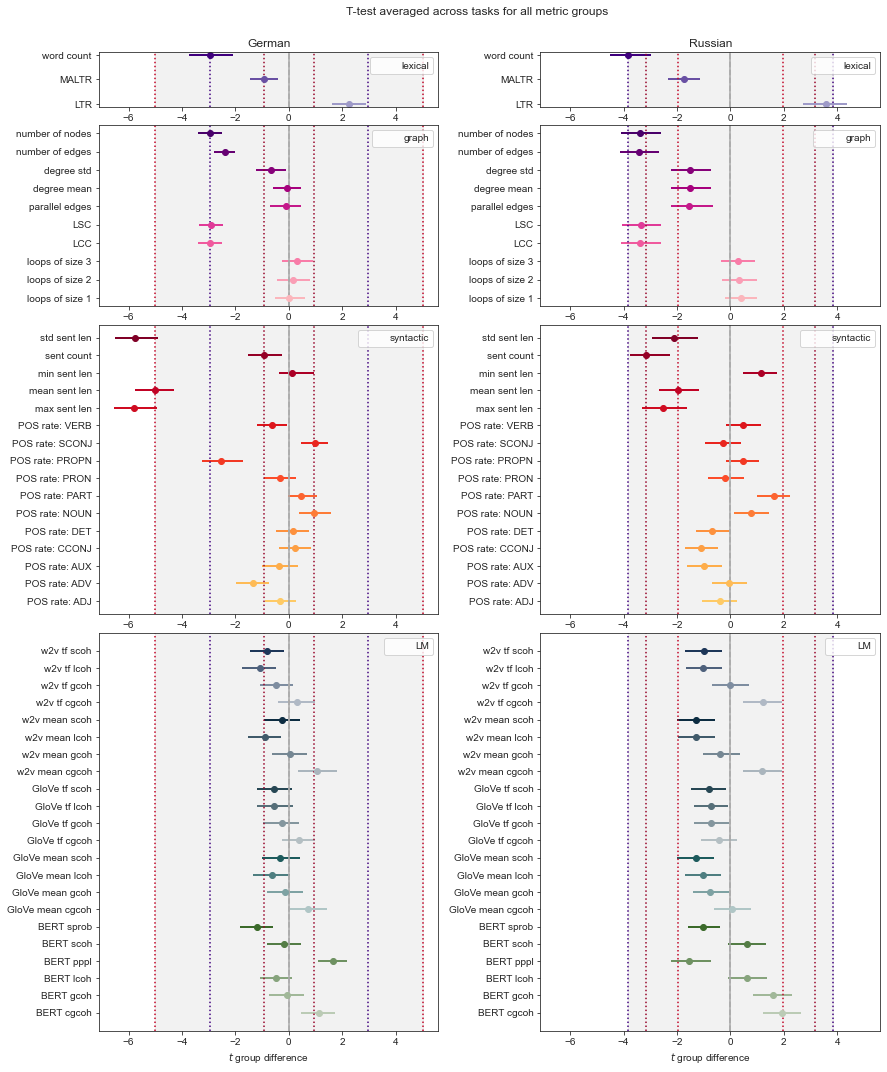

In [66]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang, 'mean', scale='group_diff', performance_metric='t')
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean', scale="group_diff"))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("T-test averaged across tasks for all metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}t-test_mean_task_all_metrics_across_languages.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [67]:
t_name_map = {'t': 'control vs psychosis', 't_sz_dep': 'depression vs psychosis', 't_dep': 'control vs depression'}

In [68]:
tru = get_data(task_mean_df, 'ru', 'mean', scale='group_diff', performance_metric='t')
tdru = get_data(task_mean_df, 'ru', 'mean', scale='group_diff_dep', performance_metric='t_dep')

In [69]:
stats.pearsonr(tru["median"], tdru["median"])

PearsonRResult(statistic=0.8507947457541727, pvalue=2.689039711552938e-15)

In [70]:
tdru['abs_median'] = tdru['median'].abs().values
tdru[['abs_median', 'metric_name']].sort_values('abs_median', ascending=False).head(10)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/210129877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdru['abs_median'] = tdru['median'].abs().values


,abs_median,metric_name
418,3.501224,LTR
428,3.257908,n_words
503,2.677424,n_sents
408,2.360560,number_of_edges
383,2.101300,LCC
413,2.101300,number_of_nodes
273,2.033721,bert_pppl
388,1.966682,LSC
488,1.956125,max_sent_len
483,1.775923,VERB


In [71]:
tru['abs_median'] = tru['median'].abs().values
tru[['abs_median', 'metric_name']].sort_values('abs_median', ascending=False).head(10)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/2064317510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tru['abs_median'] = tru['median'].abs().values


,abs_median,metric_name
427,3.846387,n_words
417,3.596437,LTR
407,3.435537,number_of_edges
382,3.384175,LCC
412,3.384175,number_of_nodes
387,3.358200,LSC
502,3.151138,n_sents
487,2.524727,max_sent_len
507,2.107102,std_sent_len
492,1.952138,mean_sent_len


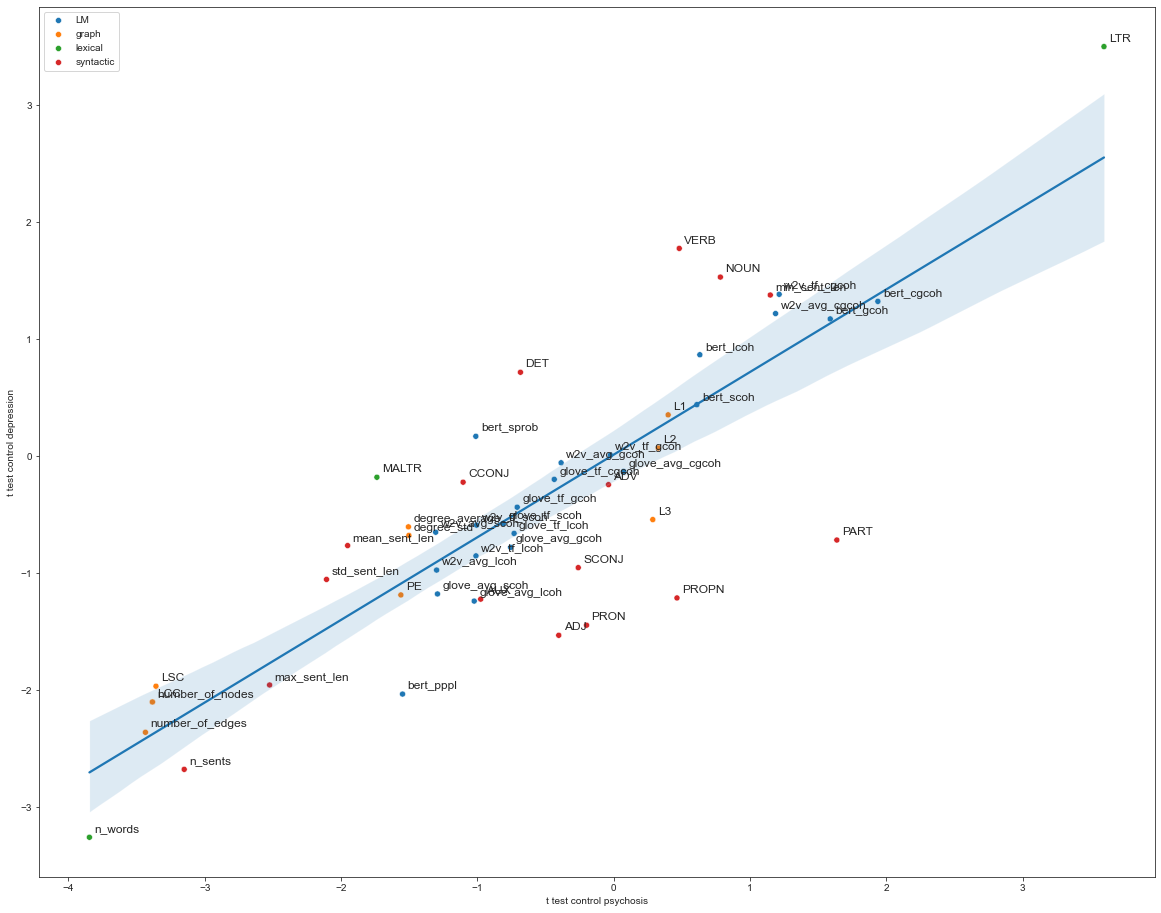

In [72]:
fig, ax = plt.subplots(figsize=(20, 16))
sns.scatterplot(x=tru["median"].values, y=tdru["median"].values, ax=ax, hue=tru["metric_group"].values)
sns.regplot(x=tru["median"], y=tdru["median"], ax=ax, scatter=False)
# add lables for each dot from tru['metric_name']
for i in range(len(tru)):
    ax.annotate(tru['metric_name'].iloc[i],  # Text label
                (tru["median"].iloc[i], tdru["median"].iloc[i]),  # Point to label
                xytext=(5, 5),  # Offset from point
                textcoords='offset points',  # Offset units
                fontsize=12)  # Text size
ax.set_xlabel('t test control psychosis')
ax.set_ylabel('t test control depression')
plt.show()

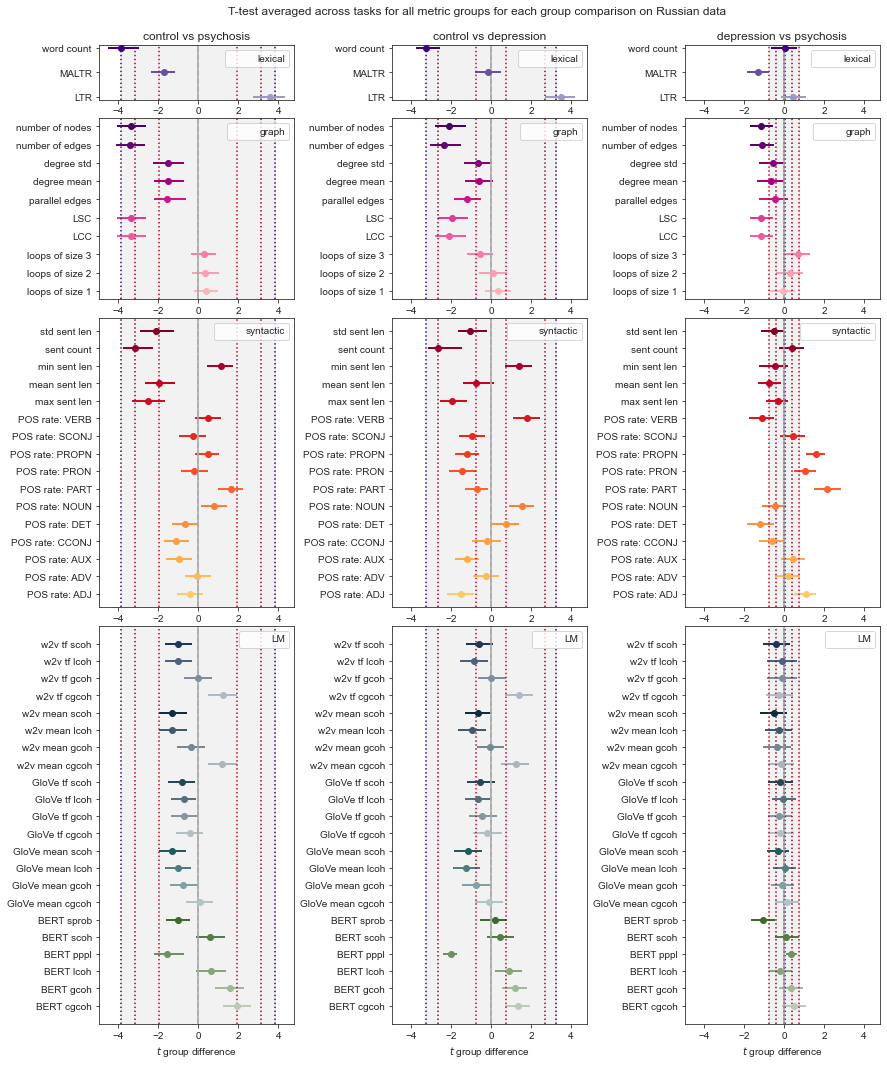

In [73]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.5)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, suffix in enumerate(["", "_dep", "_sz_dep"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang_, 'mean', metric_group, scale='group_diff' + suffix, performance_metric='t' + suffix)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang_, 'mean', scale='group_diff' + suffix, performance_metric='t' + suffix)
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang_, 'mean', scale="group_diff" + suffix))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(t_name_map['t' + suffix])
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("T-test averaged across tasks for all metric groups for each group comparison on Russian data", y=0.91)
plt.savefig(f'{PATH_FIG}{lang_}_t-test_mean_task_all_metrics_across_languages_3_group_comparisons.png', dpi=300, bbox_inches = 'tight')
plt.show()

## Correlation of performance with correlation with verbosity

each language, each task: 3 baselines by 2 t-test and panss total performance - scatter plot + correlation line: performace vs corr baseline - color metrics by group

In [74]:
def corr_nan(df, col1, col2, abs_=True):
    dropped_c = df.dropna(subset=[col1, col2])
    c1 = abs(dropped_c[col1]) if abs_ else dropped_c[col1]
    c2 = abs(dropped_c[col2]) if abs_ else dropped_c[col2]
    r_c = stats.pearsonr(c1, c2)[0]
    return r_c

In [75]:
def get_coefficient(x_name, y_name, x, y):
    df = pd.DataFrame({x_name: x, y_name: y})
    df.dropna(inplace=True)
    r, p = stats.pearsonr(df[x_name], df[y_name])
    print(f'{x_name}, {y_name}, {r:.2f}, {p:.5f}')
    return r

In [76]:
def get_coefficient_r_p(x_name, y_name, x, y):
    df = pd.DataFrame({x_name: x, y_name: y})
    df.dropna(inplace=True)
    r, p = stats.pearsonr(df[x_name], df[y_name])
    print(f'{x_name}, {y_name}, {r:.2f}, {p:.10f}')
    return r, p

In [77]:
control_name_map = {
    "n_sents": "sentence count",
    "n_words": "word count",
    "mean_sent_len": "mean sentence length"
}

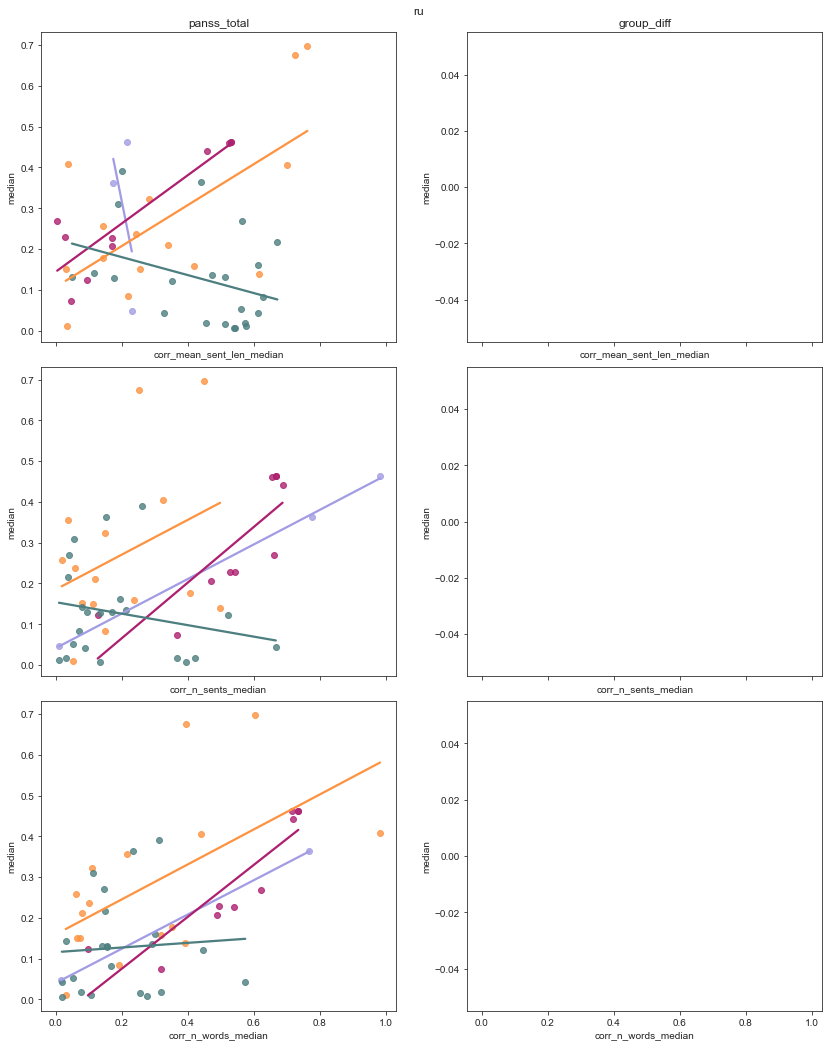

In [78]:
lang="ru"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, scale in enumerate(['panss_total', 'group_diff']):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(scale)
        task = best_task[lang]
        for metric_group in ['lexical', 'graph', 'syntactic', 'LM']:
            data = get_data(long_df, lang, task, metric_group, scale=scale)
            data = data[data["metric_name"] != control_col]
            sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), 
                        color=group_to_color[metric_group], ax=ax, ci=None)
#         data = get_data(long_df, lang, task, scale='group_diff')
#         data = data[data["metric_name"] != control_col]
#         sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
fig.suptitle(lang, y=0.9);

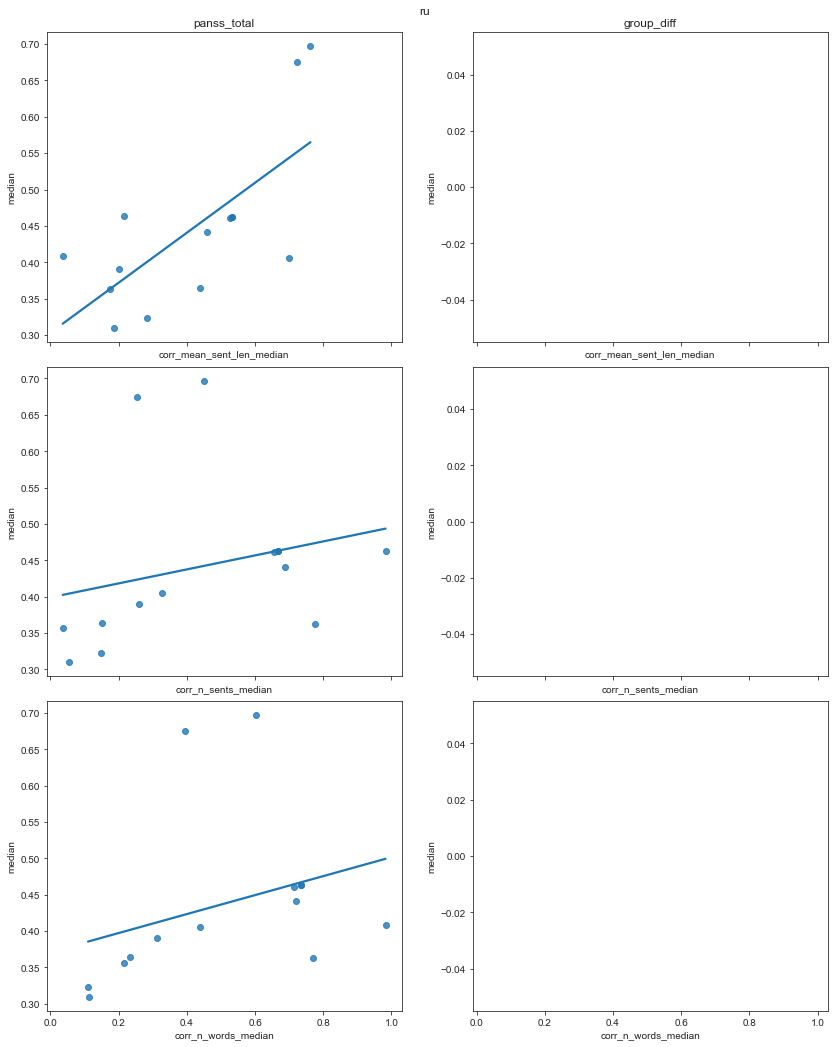

In [79]:
lang = "ru"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, scale in enumerate(['panss_total', 'group_diff']):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(scale)
        task = best_task[lang]
        data = get_data(long_df, lang, task, scale=scale)
        data = data[(data["metric_name"] != control_col) & data.apply(perfrom_above_treshold, axis=1)]
        sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
fig.suptitle(lang, y=0.9);

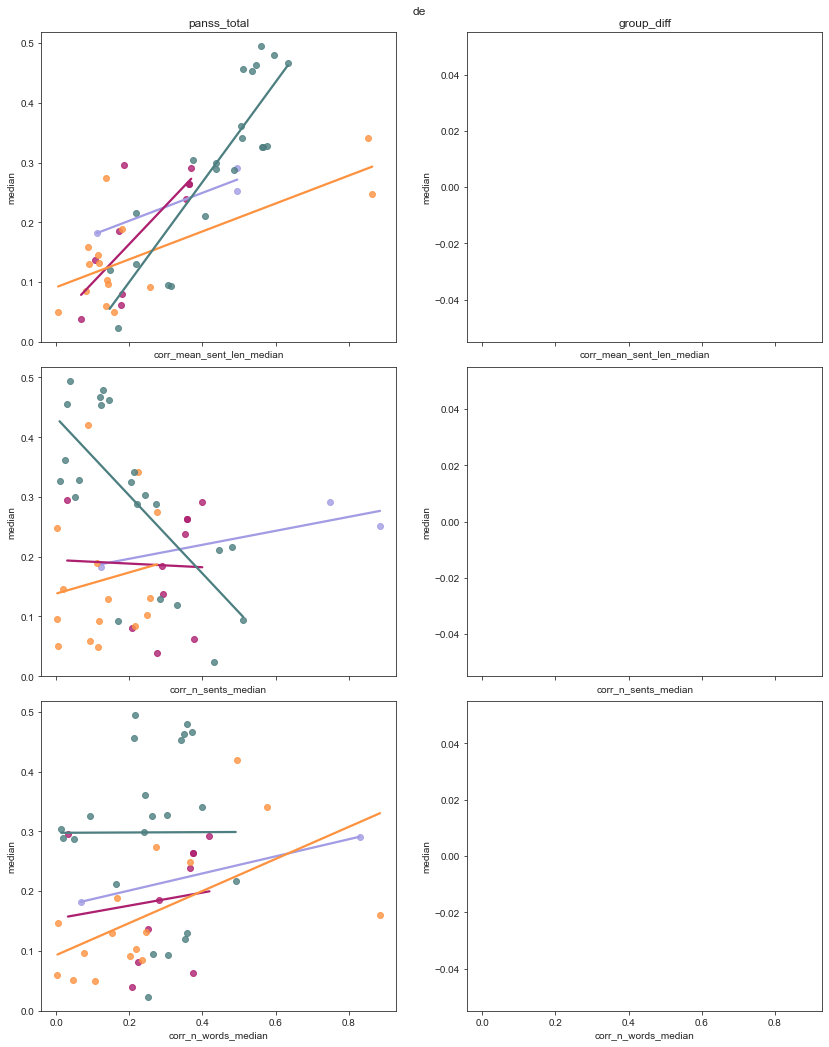

In [80]:
lang = "de"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, scale in enumerate(['panss_total', 'group_diff']):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(scale)
        task = best_task[lang]
        for metric_group in ['lexical', 'graph', 'syntactic', 'LM']:
            data = get_data(long_df, lang, task, metric_group, scale=scale)
            data = data[data["metric_name"] != control_col]
            sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), 
                        color=group_to_color[metric_group], ax=ax, ci=None)
#         data = get_data(long_df, lang, task, scale='group_diff')
#         data = data[data["metric_name"] != control_col]
#         sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
fig.suptitle(lang, y=0.9);

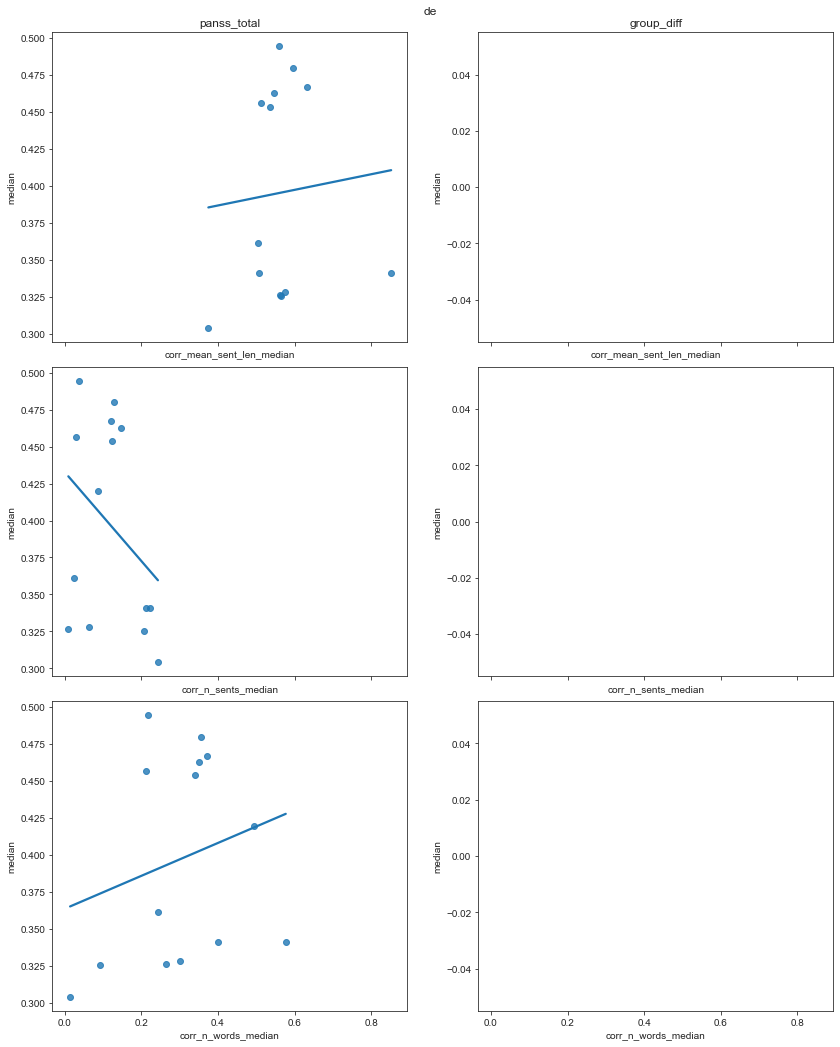

In [81]:
lang = "de"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, scale in enumerate(['panss_total', 'group_diff']):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(scale)
        task = best_task[lang]
        data = get_data(long_df, lang, task, scale=scale)
        data = data[(data["metric_name"] != control_col) & data.apply(perfrom_above_treshold, axis=1)]
        sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
fig.suptitle(lang, y=0.9);

### Correlation with verbosity against performance

In [82]:
def min_e(flt):
    for i in range(2, 10):
        thr = float(f"10e-{i}")
        if flt > thr:
            return f"10e-{i}"
    return f"10e-10"

In [83]:
de_tasks = long_df[long_df["lang"] == "de"]['task'].unique()
ru_tasks = long_df[long_df["lang"] == "ru"]['task'].unique()

In [84]:
de_tasks

array(['anger', 'fear', 'happiness', 'sadness'], dtype=object)

median, corr_mean_sent_len_median_abs, 0.60, 0.0000039755
median, corr_mean_sent_len_median, 0.78, 0.0000000000
median, corr_mean_sent_len_median, 0.42, 0.0025851320
median, corr_mean_sent_len_median, 0.40, 0.0044186028
median, corr_mean_sent_len_median, 0.10, 0.4854091260
median, corr_n_sents_median_abs, 0.33, 0.0178235450
median, corr_n_sents_median, -0.18, 0.2144545144
median, corr_n_sents_median, 0.38, 0.0063804738
median, corr_n_sents_median, 0.20, 0.1603380849
median, corr_n_sents_median, 0.52, 0.0000938537
median, corr_n_words_median_abs, 0.66, 0.0000002295
median, corr_n_words_median, 0.22, 0.1216704232
median, corr_n_words_median, 0.65, 0.0000002849
median, corr_n_words_median, 0.33, 0.0225551748
median, corr_n_words_median, 0.40, 0.0036061977
median, corr_mean_sent_len_median_abs, -0.21, 0.1394991831
median, corr_mean_sent_len_median, 0.14, 0.3292666930
median, corr_mean_sent_len_median, -0.39, 0.0046476905
median, corr_mean_sent_len_median, 0.15, 0.3062800441
median, corr_me

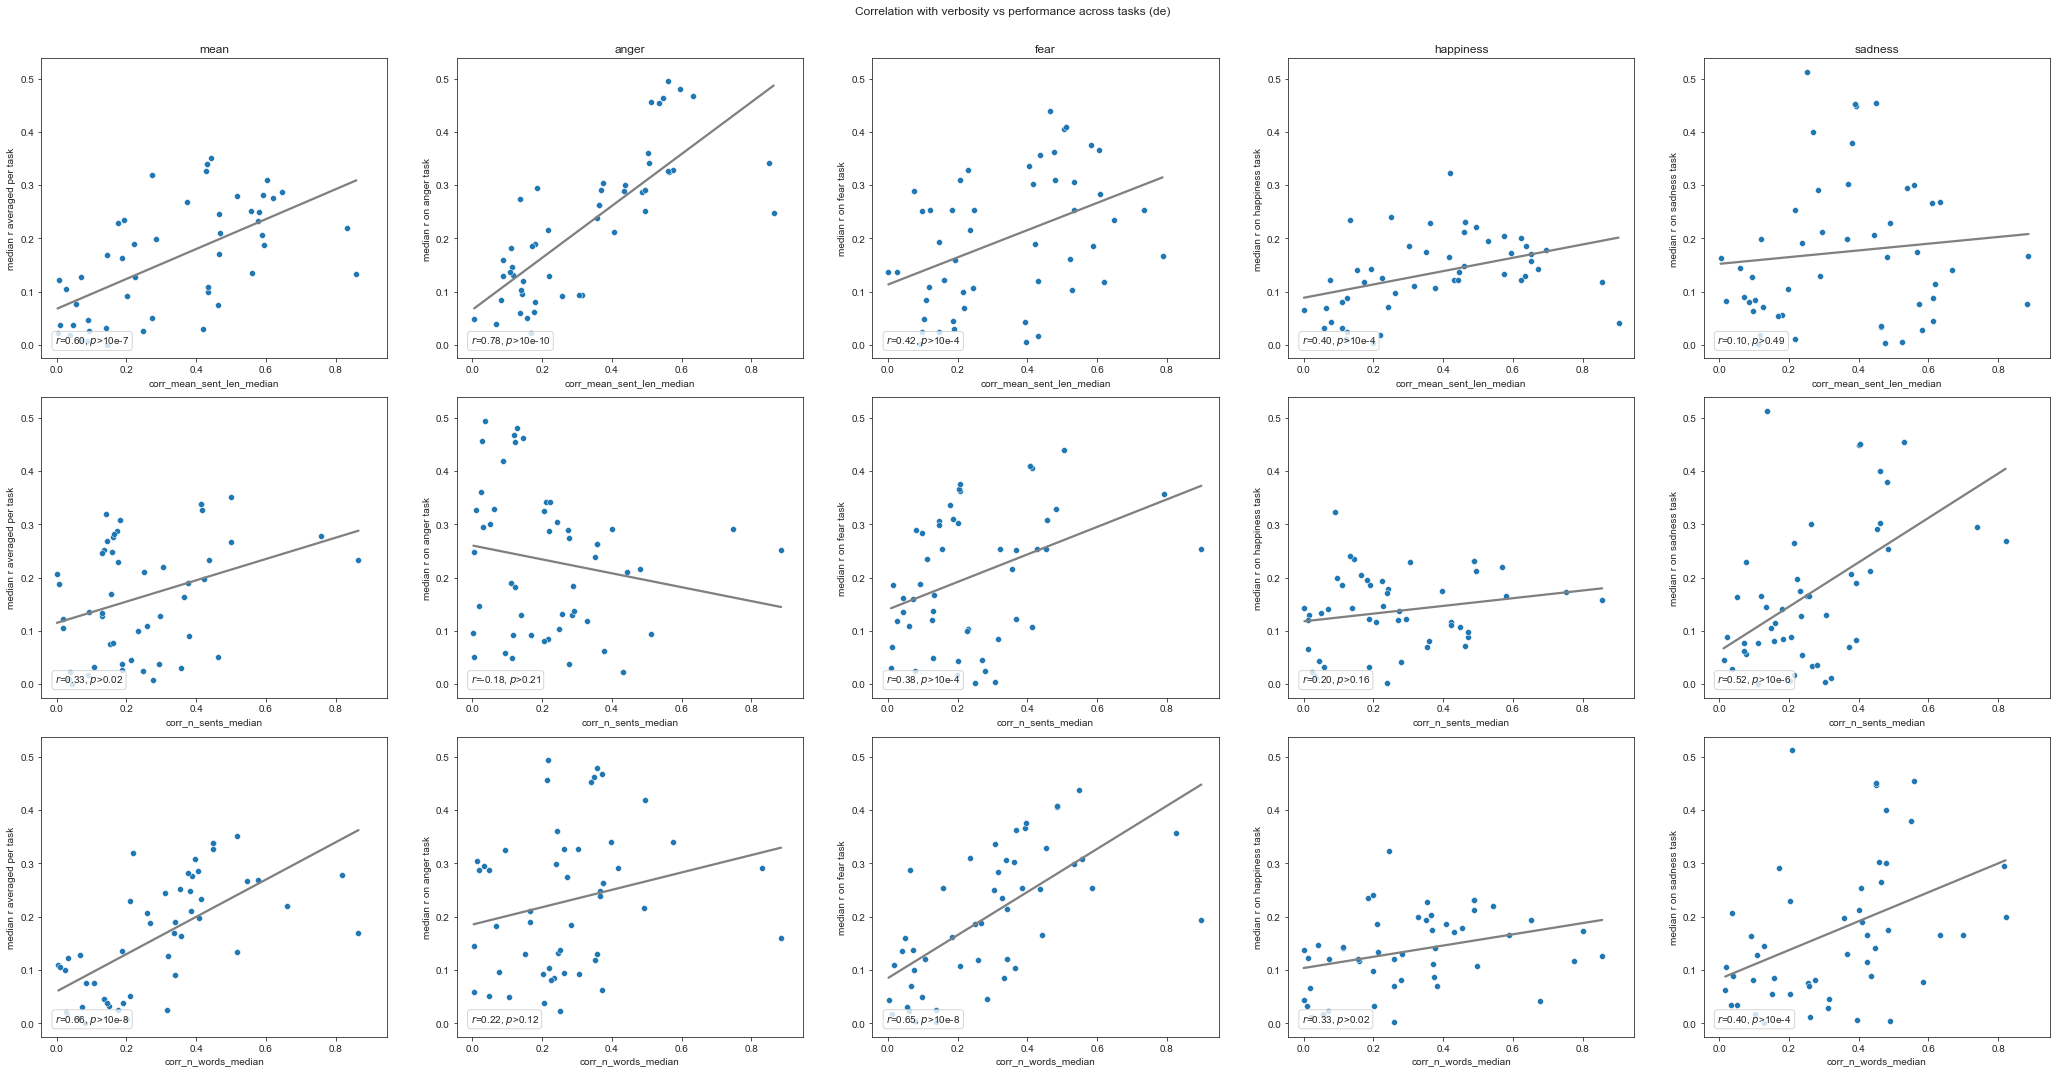

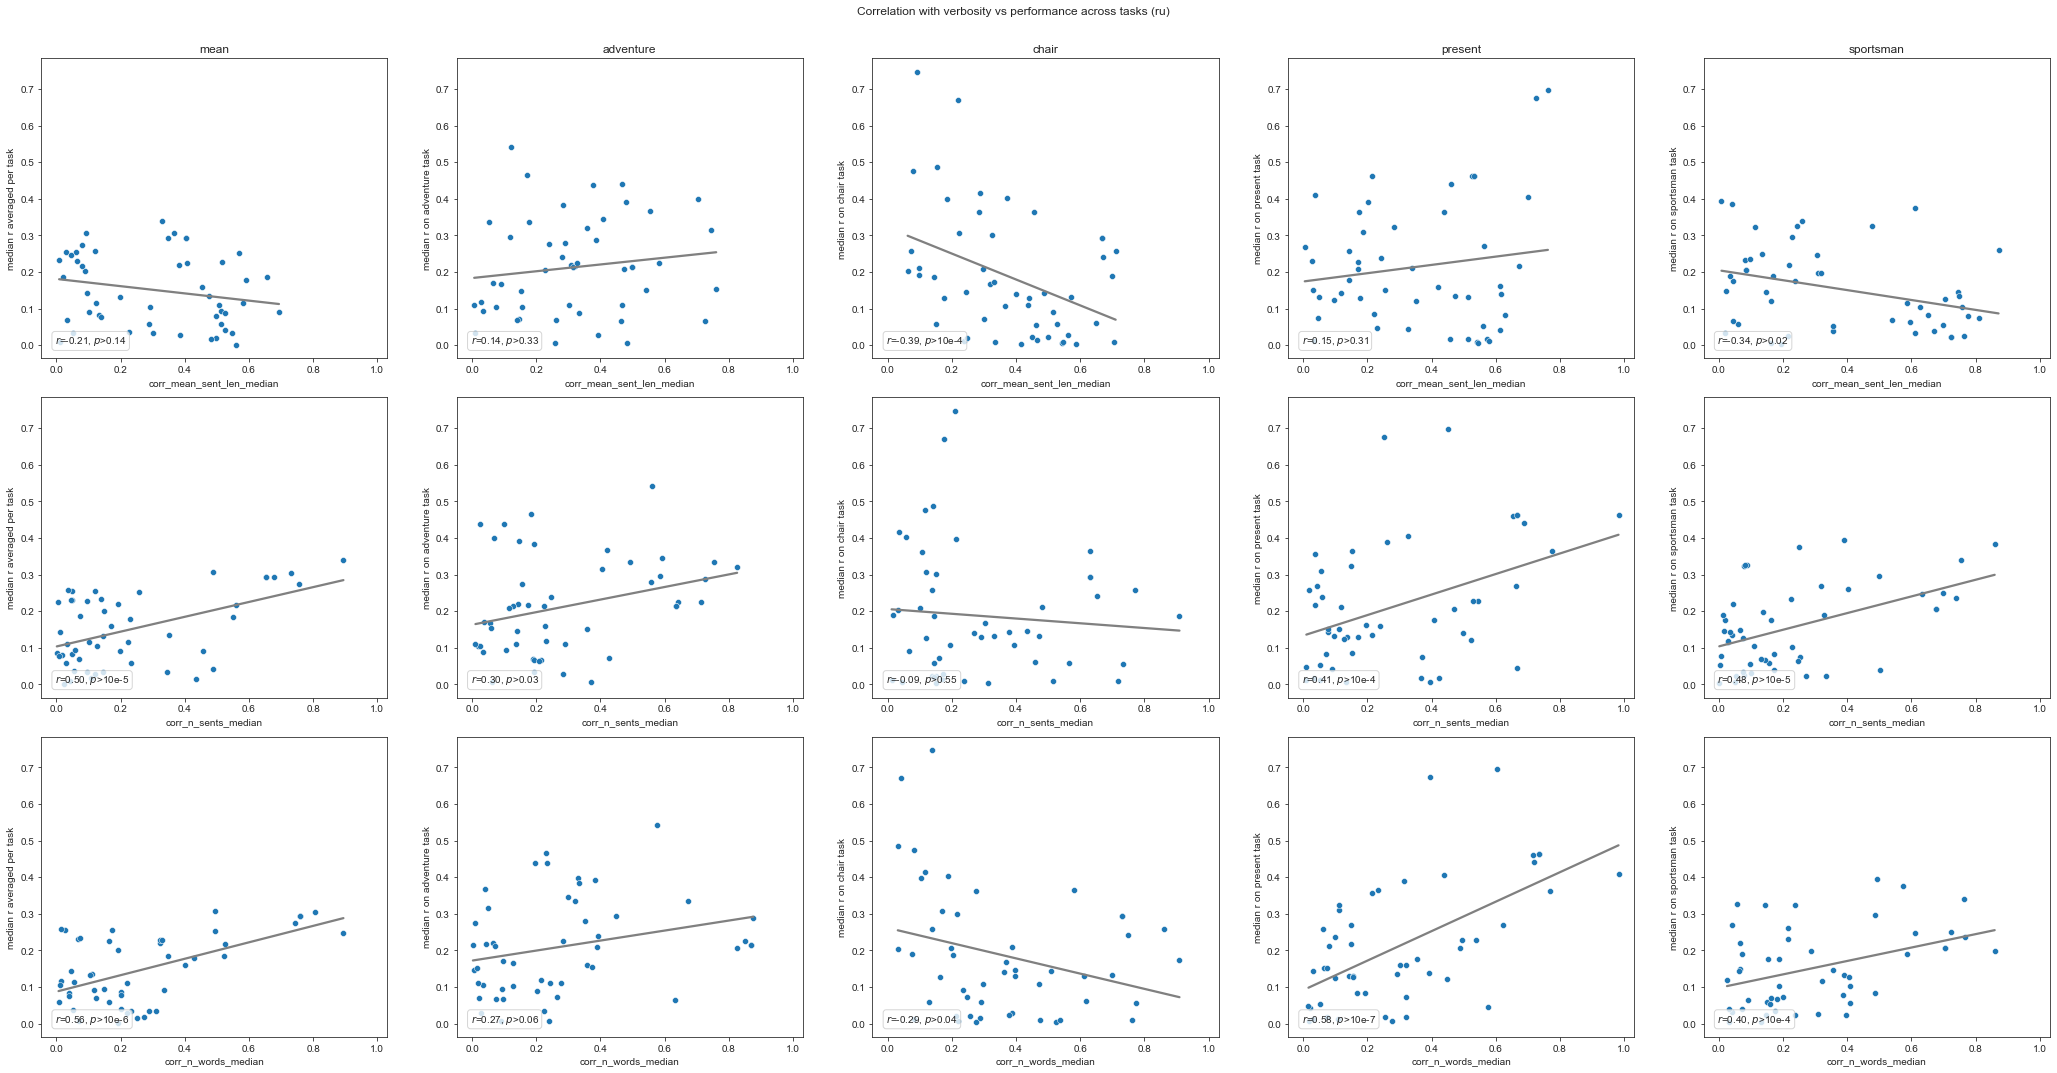

In [85]:
for lang in ['de', 'ru']:
    scale = "panss_total"
    fig, axes = plt.subplots(3, 5, figsize=(36, 18), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.13) #, wspace=0.3)
    for i, control_col in  enumerate(control_cols):
        ax = axes[i, 0]
        task = "mean"
        if i == 0:
            ax.set_title(task)
        data = get_data(task_mean_df, lang, task, scale=scale)
        data = data[(data["metric_name"] != control_col)]
        color = data.apply(perfrom_above_treshold, axis=1)
        y_name, x_name = f"corr_{control_col}_median_abs", f"median"
        y, x = abs(data['median']), abs(data[f'corr_{control_col}_median'])
        sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
        sns.scatterplot(y=y, x=x, ax=ax)
        ax.set_ylabel("median r averaged per task")
        coef, p = get_coefficient_r_p(x_name, y_name, x, y)
        p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
        ax.yaxis.set_tick_params(labelbottom=True)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8)) 
        for j, task in enumerate(de_tasks if lang == "de" else ru_tasks):
            ax = axes[i, j+1]
            if i == 0:
                ax.set_title(task)
            data = get_data(long_df, lang, task, scale=scale)
            data = data[(data["metric_name"] != control_col)]
            color = data.apply(perfrom_above_treshold, axis=1)
            y_name, x_name = f"corr_{control_col}_median", f"median"
            y, x = abs(data['median']), abs(data[f'corr_{control_col}_median'])
            sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
            sns.scatterplot(y=y, x=x, ax=ax)
            ax.set_ylabel(f"median r on {task} task")
            ax.yaxis.set_tick_params(labelleft=True)
            ax.xaxis.set_tick_params(labelbottom=True)
            coef, p = get_coefficient_r_p(x_name, y_name, x, y)
            p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
            ax.text(0.04, 0.08,
                    f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        fig.suptitle(f"Correlation with verbosity vs performance across tasks ({lang})", y=0.92);


In [86]:
## NO metric group differentiation figure

# scale = "panss_total"
# fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True, sharey=True)
# plt.subplots_adjust(hspace=0.13) #, wspace=0.3)
# 
# for i, control_col in  enumerate(control_cols):
#     for j, lang in enumerate(['de', 'ru']):
#         ax = axes[i, j]
#         if i == 0:
#             ax.set_title(f"Russian" if lang == "ru" else "German")
#         task = "mean"
#         data = get_data(task_mean_df, lang, task, scale=scale)
#         data = data[(data["metric_name"] != control_col)]
# #         color = data.apply(perfrom_above_treshold, axis=1)
#         y_name, x_name = f"corr_{control_col}_median_abs", f"median"
#         y, x = abs(data['median']), abs(data[f'corr_{control_col}_median'])
#         
# 
#         sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
#         sns.scatterplot(y=y, x=x, ax=ax)
#         
#         
#         ax.yaxis.set_tick_params(labelleft=True)
#         ax.xaxis.set_tick_params(labelbottom=True)
#         ax.set_ylabel("$r$ symptom severity correlation")
#         ax.set_xlabel(control_name_map[control_col])
#         
#         coef, p = get_coefficient_r_p(x_name, y_name, x, y)
#         p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
#         ax.text(0.04, 0.08,
#                 f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
#                 fontsize=10, verticalalignment='top',
#                 bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
# fig.suptitle("Correlation with verbosity vs median correlation with PANSS total averaged across tasks (absolute values)", y=0.92);
# plt.savefig(f'{PATH_FIG}verbosity_correlation_performance_avergae.png', dpi=300, bbox_inches = 'tight')
# fig.show();

## Best metrics perform across tasks
difference between tasks: SD(performance) / (mean task performance) - scatter vs mean task performance on t-test and panss total - color metrics by group

In [87]:
def diff_task_performance(df, metric_name, lang, scale):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['scale'] == scale)]['median'].abs()
    return np.std(data) / np.mean(data)

In [88]:
def best_task_performance(df, metric_name, lang, scale):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['scale'] == scale)]['median'].abs()
    return np.nanmax(data)

In [89]:
dict_diff = {"metric group": [], 
             "diff_group_diff_de": [], "diff_group_diff_ru": [], 
             "diff_panss_total_de": [], "diff_panss_total_ru": [],
             "diff_ps_r_dep.severity_ru": [],
             
             "group_diff_de": [], "group_diff_ru": [], 
             "panss_total_de": [], "panss_total_ru": [],
             "ps_r_dep.severity_ru": [], 
             
             "best_group_diff_de": [], "best_group_diff_ru": [], 
             "best_panss_total_de": [], "best_panss_total_ru": [],
             "best_ps_r_dep.severity_ru": []}
for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        for scale in ['panss_total', 'group_diff', "ps_r_dep.severity"]:
            if lang == 'de' and scale == "ps_r_dep.severity":
                continue
            diff = diff_task_performance(long_df, metric_name, lang, scale)
            mean = mean_task_performance(long_df, metric_name, lang, scale)
            best = best_task_performance(long_df, metric_name, lang, scale)
            dict_diff[f"diff_{scale}_{lang}"].append(diff)
            if lang == "ru" and scale == "group_diff":
                dict_diff["metric group"].append(long_df[long_df['metric_name'] == metric_name]["metric_group"].values[0])
            dict_diff[f"{scale}_{lang}"].append(mean)
            dict_diff[f"best_{scale}_{lang}"].append(best)

In [90]:
diff_df = pd.DataFrame.from_dict(dict_diff)
diff_df.index = list(metric_to_color.keys())

In [91]:
slice_diff_df = diff_df[[f"diff_panss_total_de", f"panss_total_de"]]

In [92]:
# def get_coefficient(x_name, y_name, x, y):
#     df = pd.DataFrame({x_name: x, y_name: y})
#     df = sm.add_constant(df, prepend=False)
#     mod = sm.OLS(df[y_name], df[x_name])
#     res = mod.fit()
#     print(f'{x_name}, {y_name}, {res.rsquared:.2f}, {res.pvalues[x_name]:.5f}')
# #     print(res.summary())
#     return res.rsquared

In [93]:
get_coefficient(f"panss_total_de", f"diff_panss_total_de", diff_df[f"panss_total_de"], diff_df[f"diff_panss_total_de"])

panss_total_de, diff_panss_total_de, -0.54, 0.00004


-0.5420760142493921

panss_total_ru, diff_panss_total_ru, -0.49, 0.00028
group_diff_ru, diff_group_diff_ru, -0.68, 0.00000
ps_r_dep.severity_ru, diff_ps_r_dep.severity_ru, -0.49, 0.00028


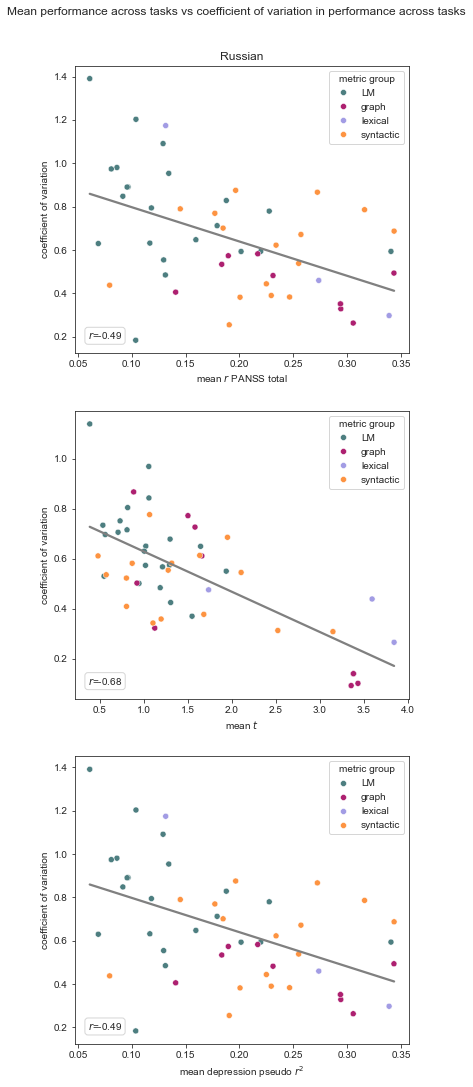

In [94]:
fig, axes = plt.subplots(3, 1, figsize=(6, 18))
for i, scale in enumerate(['panss_total', 'group_diff', 'ps_r_dep.severity']):
    lang = 'ru'
    ax = axes[i]
    if i == 0:
        ax.set_title(f"Russian" if lang == "ru" else "German")
    y_name, x_name = f"diff_{scale}_{lang}", f"{scale}_{lang}"
    y, x = diff_df[y_name], diff_df[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df["metric group"], ax=ax, palette=group_to_color)
    sns.regplot(y=y, x=x, 
                ci=None, scatter=False, color='grey', ax=ax)
    ax.set_ylabel('coefficient of variation')
    label = {'panss_total': 'mean $r$ PANSS total',
             'group_diff': "mean $t$",
             'ps_r_dep.severity': 'mean depression pseudo $r^2$'}.get(scale, '...')
    coef = get_coefficient(x_name, y_name, x, y)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
    ax.set_xlabel(label)
fig.suptitle("Mean performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
# plt.savefig(f'{PATH_FIG}performance_vs_CV_across_tasks.png', dpi=dpi, bbox_inches = 'tight')

panss_total_de, diff_panss_total_de, -0.54, 0.00004
panss_total_ru, diff_panss_total_ru, -0.49, 0.00028
group_diff_de, diff_group_diff_de, -0.62, 0.00000
group_diff_ru, diff_group_diff_ru, -0.68, 0.00000


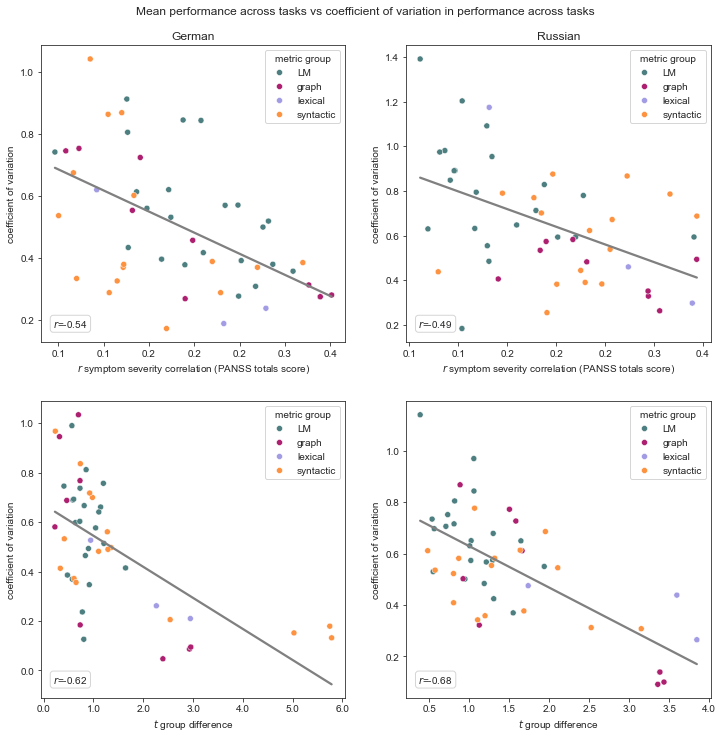

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, scale in enumerate(['panss_total', 'group_diff']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{scale}_{lang}", f"{scale}_{lang}"
        y, x = diff_df[y_name], diff_df[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df["metric group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        ax.set_ylabel('coefficient of variation')
        label = '$r$ symptom severity correlation (PANSS totals score)' if i == 0 else "$t$ group difference"
        ax.set_xlabel(label)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Mean performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
plt.savefig(f'{PATH_FIG}performance_vs_CV_across_tasks.png', dpi=dpi, bbox_inches = 'tight')

#### for overview

panss_total_de, diff_panss_total_de, -0.54, 0.00004
panss_total_ru, diff_panss_total_ru, -0.49, 0.00028


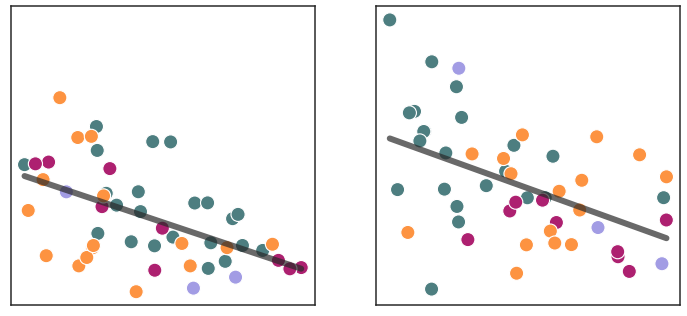

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
scale = 'panss_total'

for j, lang in enumerate(["de", "ru"]):
    ax = axes[j]
    y_name, x_name = f"diff_{scale}_{lang}", f"{scale}_{lang}"
    y, x = diff_df[y_name], diff_df[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df["metric group"], ax=ax, palette=group_to_color, legend=False, s=200, rasterized=True)
    sns.regplot(y=y, x=x, ci=None, scatter=False, color='#292929', ax=ax, line_kws={'linewidth':6, 'alpha': 0.7})
    coef = get_coefficient(x_name, y_name, x, y)
    ax.set_ylabel('')
    ax.set_xlabel('', fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    [x.set_linewidth(1.5) for x in ax.spines.values()]
# fig.suptitle("Mean performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
plt.savefig(f'{PATH_FIG}performance_vs_CV_for_overview.svg', dpi=dpi, bbox_inches = 'tight', transparent=True)

best_panss_total_de, diff_panss_total_de, -0.16, 0.25595
best_panss_total_ru, diff_panss_total_ru, -0.06, 0.67088
best_group_diff_de, diff_group_diff_de, -0.46, 0.00060
best_group_diff_ru, diff_group_diff_ru, -0.43, 0.00187


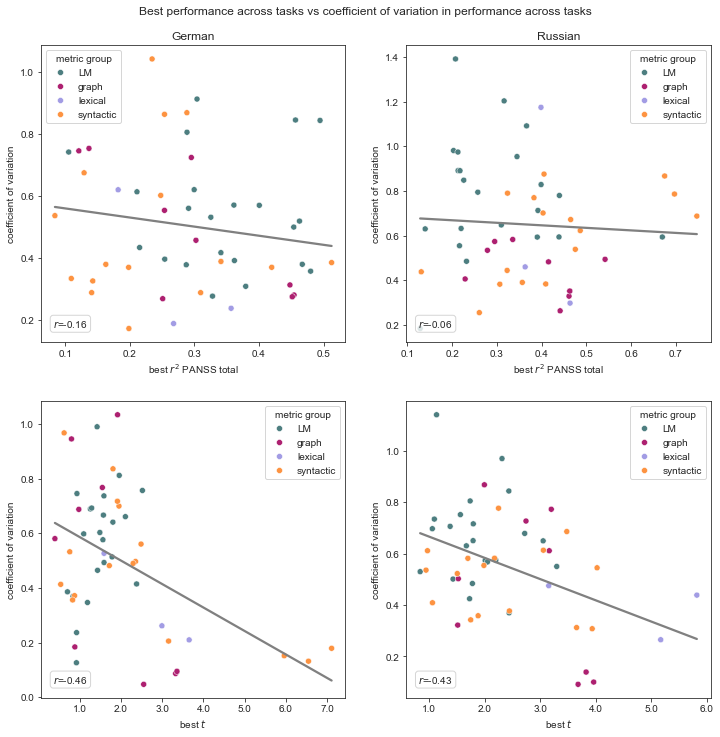

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, scale in enumerate(['panss_total', 'group_diff']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{scale}_{lang}", f"best_{scale}_{lang}"
        y, x = diff_df[y_name], diff_df[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df["metric group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        ax.set_ylabel('coefficient of variation')
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        label = 'best $r^2$ PANSS total' if i == 0 else "best $t$"
        ax.set_xlabel(label)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Best performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
plt.savefig(f'{PATH_FIG}best_performance_vs_CV_across_tasks.png', dpi=dpi, bbox_inches = 'tight')

## Best metrics perform across scales
difference between scales: SD(performance) / (mean scale performance) - scatter vs mean scale performance on t-test and - color metrics by group

normalize each scale performance z transform ((val) - mean(vals)) / std(vals)

In [98]:
def normalize_scale_values(df, scale, lang, task):
    data = df[(df['lang'] == lang) & (df['scale'] == scale) & (df['task'] == task)]['median'].values
    return (data - np.nanmean(data)) / np.nanstd(data)

In [99]:
long_df["normalized_median"] = np.nan

In [100]:
for lang in ["de", "ru"]:
    for task in long_df[long_df["lang"] == lang]["task"].unique():
        for scale in long_df[long_df["lang"] == lang]["scale"].unique():
            vals = normalize_scale_values(long_df, scale, lang, task)
            long_df.loc[(long_df["lang"] == lang) 
                    & (long_df["task"] == task) 
                    & (long_df["scale"] == scale), "normalized_median"] = vals

In [101]:
def diff_scale_performance(df, metric_name, lang, task):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['task'] == task)]['normalized_median'].abs()
    return np.nanstd(data) / np.nanmean(data)

In [102]:
def mean_scale_performance(df, metric_name, lang, task):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['task'] == task)]['normalized_median'].abs()
    return np.nanmean(data)

In [103]:
def max_scale_performance(df, metric_name, lang, task):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['task'] == task)]['normalized_median'].abs()
    return np.nanmax(data)

In [104]:
def diff_max_mean_task_scale_performance(df, metric_name, lang):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name)]
    ress = []
    for task in data['task'].unique():
        ress.append(np.nanmean(data[data['task'] == task]['normalized_median'].abs()))
    return np.nanstd(ress) / np.nanmean(ress), np.nanmax(ress), np.nanmean(ress)

In [105]:
dict_diff_ = {"metric group": [], 
             'diff_de': [], 'diff_ru': [],
             'best_perf_de': [], 'best_perf_ru': [],
              'perf_de': [], 'perf_ru': []
             }


for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        diff, best, mean = diff_max_mean_task_scale_performance(long_df, metric_name, lang)
        if lang == "de":
            dict_diff_["metric group"].append(long_df[long_df['metric_name'] == metric_name]["metric_group"].values[0])
        dict_diff_[f"diff_{lang}"].append(diff)
        dict_diff_[f"best_perf_{lang}"].append(best)
        dict_diff_[f"perf_{lang}"].append(mean)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/931595090.py:5: RuntimeWarning: Mean of empty slice
  ress.append(np.nanmean(data[data['task'] == task]['normalized_median'].abs()))


In [106]:
diff_df_ = pd.DataFrame.from_dict(dict_diff_)
diff_df_.index = list(metric_to_color.keys())

perf_de, diff_de, -0.31, 0.02907
perf_ru, diff_ru, -0.21, 0.14260


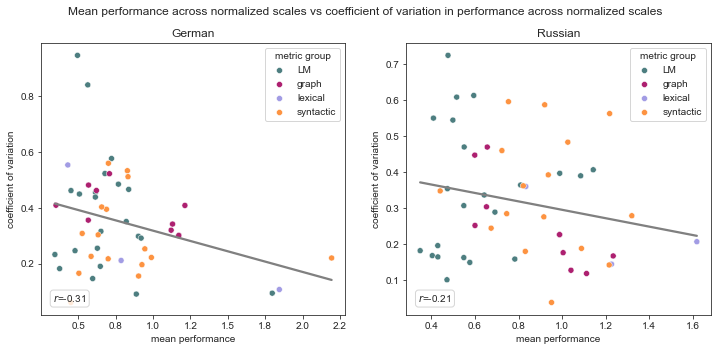

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j, lang in enumerate(["de", "ru"]):
    task = long_df[long_df["lang"] == lang]["task"].unique()
    ax = axes[j]
    ax.set_title(f"Russian" if lang == "ru" else "German")
    y_name, x_name = f"diff_{lang}", f"perf_{lang}"
    y, x = diff_df_[y_name], diff_df_[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df_["metric group"], ax=ax, palette=group_to_color)
    sns.regplot(y=y, x=x, 
                ci=None, scatter=False, color='grey', ax=ax)
    coef = get_coefficient(x_name, y_name, x, y)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
    ax.set_ylabel('coefficient of variation')
    ax.set_xlabel(f'mean performance')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Mean performance across normalized scales vs coefficient of variation in performance across normalized scales");
plt.savefig(f'{PATH_FIG}mean_performance_vs_CV_across_normalized_scales_task_averaged.png', dpi=dpi, bbox_inches = 'tight')

best_perf_de, diff_de, 0.09, 0.51503
best_perf_ru, diff_ru, 0.26, 0.06942


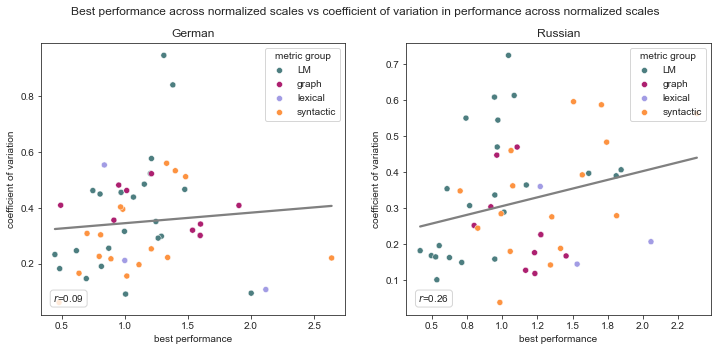

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j, lang in enumerate(["de", "ru"]):
    task = long_df[long_df["lang"] == lang]["task"].unique()
    ax = axes[j]
    ax.set_title(f"Russian" if lang == "ru" else "German")
    y_name, x_name = f"diff_{lang}", f"best_perf_{lang}"
    y, x = diff_df_[y_name], diff_df_[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df_["metric group"], ax=ax, palette=group_to_color)
    sns.regplot(y=y, x=x, 
                ci=None, scatter=False, color='grey', ax=ax)
    coef = get_coefficient(x_name, y_name, x, y)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
    ax.set_ylabel('coefficient of variation')
    ax.set_xlabel(f'best performance')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Best performance across normalized scales vs coefficient of variation in performance across normalized scales");
plt.savefig(f'{PATH_FIG}best_performance_vs_CV_across_normalized_scales_task_averaged.png', dpi=dpi, bbox_inches = 'tight')

In [109]:
dict_diff_ = {"metric group": [], 
             'diff_anger_de': [], 'diff_fear_de': [],
             'diff_happiness_de': [], 'diff_sadness_de': [],
             'diff_adventure_ru': [], 'diff_chair_ru': [],
             'diff_present_ru': [], 'diff_sportsman_ru': [],
             
             'perf_anger_de': [], 'perf_fear_de': [],
             'perf_happiness_de': [], 'perf_sadness_de': [], 
             
             'perf_adventure_ru': [], 'perf_chair_ru': [], 
             'perf_present_ru': [], 'perf_sportsman_ru': [],
             
             'best_perf_anger_de': [], 'best_perf_fear_de': [],
             'best_perf_happiness_de': [], 'best_perf_sadness_de': [], 
             
             'best_perf_adventure_ru': [], 'best_perf_chair_ru': [], 
             'best_perf_present_ru': [], 'best_perf_sportsman_ru': []}


for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        for task in long_df[long_df["lang"] == lang]["task"].unique():
            diff = diff_scale_performance(long_df, metric_name, lang, task)
            mean = mean_scale_performance(long_df, metric_name, lang, task)
            best = max_scale_performance(long_df, metric_name, lang, task)
            dict_diff_[f"diff_{task}_{lang}"].append(diff)
            if lang == "de" and task == "anger":
                dict_diff_["metric group"].append(long_df[long_df['metric_name'] == metric_name]["metric_group"].values[0])
            dict_diff_[f"perf_{task}_{lang}"].append(mean)
            dict_diff_[f"best_perf_{task}_{lang}"].append(best)

/Users/galina.ryazanskaya/miniconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_81748/1269763494.py:3: RuntimeWarning: Mean of empty slice
  return np.nanstd(data) / np.nanmean(data)


In [110]:
diff_df_ = pd.DataFrame.from_dict(dict_diff_)
diff_df_.index = list(metric_to_color.keys())

perf_anger_de, diff_anger_de, -0.60, 0.00000
perf_adventure_ru, diff_adventure_ru, -0.31, 0.02679
perf_fear_de, diff_fear_de, -0.42, 0.00190
perf_chair_ru, diff_chair_ru, -0.41, 0.00259
perf_happiness_de, diff_happiness_de, -0.37, 0.00794
perf_present_ru, diff_present_ru, -0.73, 0.00000
perf_sadness_de, diff_sadness_de, -0.43, 0.00180
perf_sportsman_ru, diff_sportsman_ru, -0.69, 0.00000


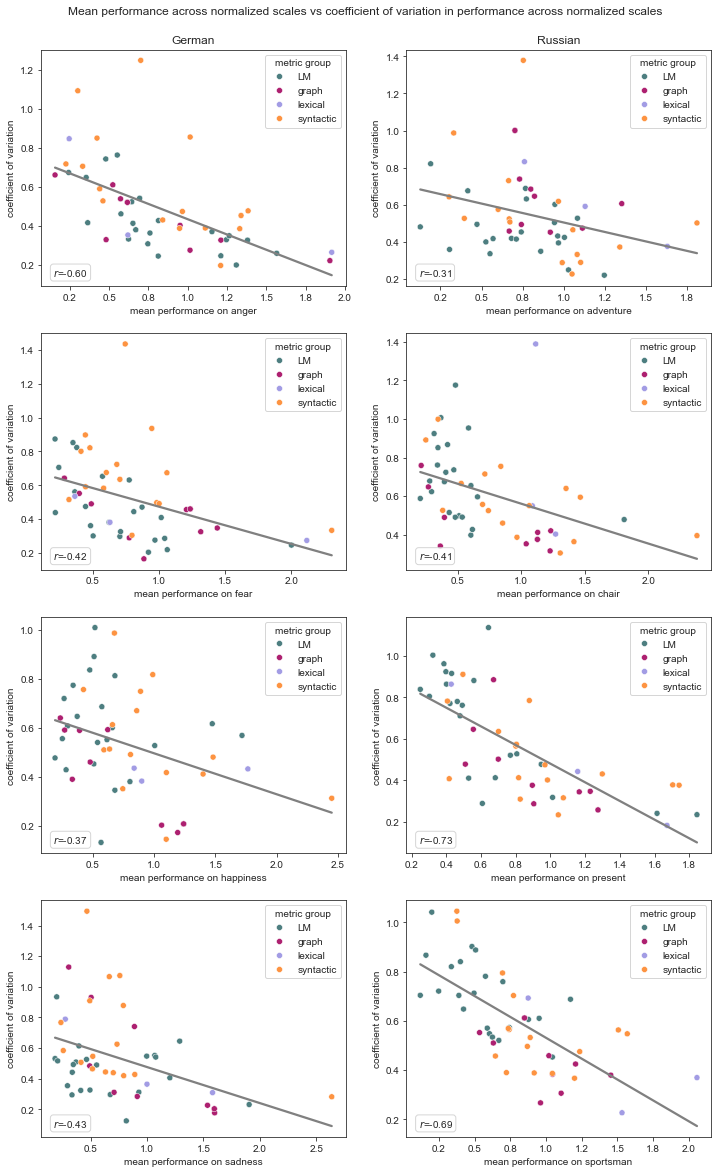

In [111]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
for i in range(4):
    for j, lang in enumerate(["de", "ru"]):
        task = long_df[long_df["lang"] == lang]["task"].unique()[i]
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{task}_{lang}", f"perf_{task}_{lang}"
        y, x = diff_df_[y_name], diff_df_[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df_["metric group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        ax.set_ylabel('coefficient of variation')
        ax.set_xlabel(f'mean performance on {task}')
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Mean performance across normalized scales vs coefficient of variation in performance across normalized scales", y=0.91);
plt.savefig(f'{PATH_FIG}performance_vs_CV_across_normalized_scales.png', dpi=dpi, bbox_inches = 'tight')

best_perf_anger_de, diff_anger_de, -0.07, 0.62810
best_perf_adventure_ru, diff_adventure_ru, 0.26, 0.07030
best_perf_fear_de, diff_fear_de, 0.18, 0.20455
best_perf_chair_ru, diff_chair_ru, 0.07, 0.60816
best_perf_happiness_de, diff_happiness_de, 0.02, 0.87148
best_perf_present_ru, diff_present_ru, -0.18, 0.20175
best_perf_sadness_de, diff_sadness_de, 0.11, 0.43099
best_perf_sportsman_ru, diff_sportsman_ru, -0.42, 0.00202


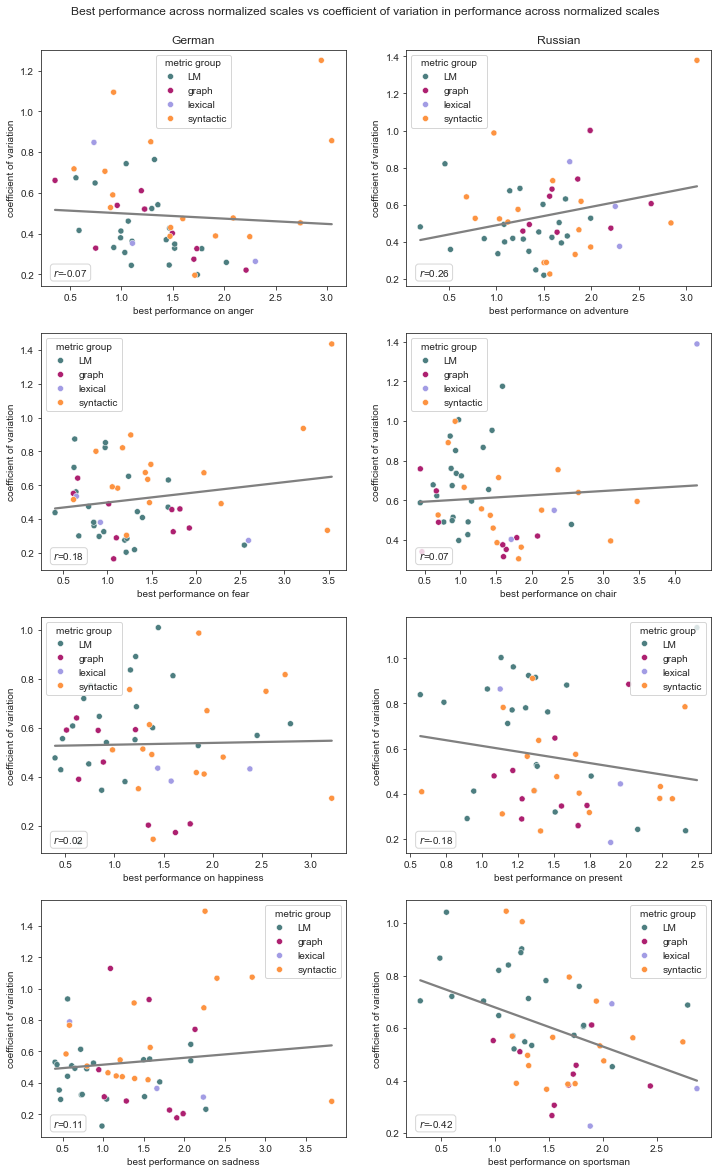

In [112]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
for i in range(4):
    for j, lang in enumerate(["de", "ru"]):
        task = long_df[long_df["lang"] == lang]["task"].unique()[i]
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{task}_{lang}", f"best_perf_{task}_{lang}"
        y, x=diff_df_[y_name], diff_df_[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df_["metric group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        ax.set_ylabel('coefficient of variation')
        ax.set_xlabel(f'best performance on {task}')
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Best performance across normalized scales vs coefficient of variation in performance across normalized scales", y=0.91);
plt.savefig(f'{PATH_FIG}best_performance_vs_CV_across_normalized_scales.png', dpi=dpi, bbox_inches = 'tight')

## Task differences (ICC2)

In [113]:
long_df[(long_df['lang'] == lang) & (long_df['scale'] == scale)]

,lang,subset,task,scale,performance_metric,metric_group,metric_name,median,mean,CI_low,...,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high,normalized_median
1224,ru,psychosis_only,adventure,ps_r_td.severity,ps_r,LM,bert_cgcoh,0.170392,0.177156,0.035575,...,0.072581,-0.038598,-0.042117,-0.132603,0.055157,-0.096448,-0.101256,-0.202547,0.005319,1.342881
1225,ru,psychosis_only,adventure,ps_r_td.severity,ps_r,LM,bert_gcoh,0.105614,0.114910,-0.034054,...,0.060013,0.018802,0.014178,-0.072230,0.105403,-0.035200,-0.043410,-0.132325,0.045716,1.044277
1226,ru,psychosis_only,adventure,ps_r_td.severity,ps_r,LM,bert_lcoh,0.005870,0.006728,-0.113042,...,-0.161687,-0.061509,-0.059668,-0.174017,0.051290,-0.239543,-0.235934,-0.322475,-0.144988,0.584497
1227,ru,psychosis_only,adventure,ps_r_td.severity,ps_r,LM,bert_pppl,0.103460,0.074875,-0.077069,...,-0.013456,-0.025227,-0.021282,-0.096204,0.046778,-0.128673,-0.130532,-0.191337,-0.066826,1.034350
1228,ru,psychosis_only,adventure,ps_r_td.severity,ps_r,LM,bert_scoh,0.068998,0.068681,-0.052102,...,-0.132763,0.189116,0.185582,0.071376,0.310862,0.021876,0.019300,-0.089510,0.131275,0.875492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5095,ru,psychosis_only,sportsman,ps_r_td.severity,ps_r,syntactic,max_sent_len,-0.375584,-0.348052,-0.490953,...,0.690076,0.249814,0.217714,0.102101,0.350032,0.572851,0.571859,0.506342,0.646879,-1.705712
5096,ru,psychosis_only,sportsman,ps_r_td.severity,ps_r,syntactic,mean_sent_len,-0.269688,-0.273406,-0.345713,...,NaN,-0.319225,-0.273888,-0.461166,-0.115835,0.039243,0.118008,-0.120148,0.422548,-1.109879
5097,ru,psychosis_only,sportsman,ps_r_td.severity,ps_r,syntactic,min_sent_len,-0.260722,-0.312016,-0.394818,...,0.916336,-0.402655,-0.364965,-0.513045,-0.269299,-0.214822,-0.165075,-0.328201,0.011866,-1.059428
5098,ru,psychosis_only,sportsman,ps_r_td.severity,ps_r,syntactic,n_sents,-0.196998,-0.179308,-0.335034,...,-0.115835,NaN,NaN,NaN,NaN,0.859524,0.846455,0.809561,0.900680,-0.700877


In [114]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'de') & (long_df['scale'] == 'panss_total')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.562747,6.148030,49,150,3.546936e-18,"[0.43, 0.69]"
1,ICC2,Single random raters,0.566652,6.700278,49,147,1.341602e-19,"[0.43, 0.7]"
2,ICC3,Single fixed raters,0.587641,6.700278,49,147,1.341602e-19,"[0.45, 0.71]"
3,ICC1k,Average raters absolute,0.837346,6.148030,49,150,3.546936e-18,"[0.75, 0.9]"
4,ICC2k,Average random raters,0.839498,6.700278,49,147,1.341602e-19,"[0.75, 0.9]"
5,ICC3k,Average fixed raters,0.850752,6.700278,49,147,1.341602e-19,"[0.77, 0.91]"


In [115]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'de') & (long_df['scale'] == 'group_diff')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.799300,16.930270,49,150,4.831392e-41,"[0.71, 0.87]"
1,ICC2,Single random raters,0.800263,18.728886,49,147,3.988987e-43,"[0.71, 0.87]"
2,ICC3,Single fixed raters,0.815913,18.728886,49,147,3.988987e-43,"[0.74, 0.88]"
3,ICC1k,Average raters absolute,0.940934,16.930270,49,150,4.831392e-41,"[0.91, 0.96]"
4,ICC2k,Average random raters,0.941267,18.728886,49,147,3.988987e-43,"[0.91, 0.96]"
5,ICC3k,Average fixed raters,0.946607,18.728886,49,147,3.988987e-43,"[0.92, 0.97]"


In [116]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'ru') & (long_df['scale'] == 'panss_total')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.349676,3.150784,50,153,3.317629e-08,"[0.21, 0.51]"
1,ICC2,Single random raters,0.361784,3.567003,50,150,1.081133e-09,"[0.22, 0.52]"
2,ICC3,Single fixed raters,0.390894,3.567003,50,150,1.081133e-09,"[0.25, 0.54]"
3,ICC1k,Average raters absolute,0.682619,3.150784,50,153,3.317629e-08,"[0.51, 0.8]"
4,ICC2k,Average random raters,0.693953,3.567003,50,150,1.081133e-09,"[0.53, 0.81]"
5,ICC3k,Average fixed raters,0.719653,3.567003,50,150,1.081133e-09,"[0.57, 0.83]"


In [117]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'ru') & (long_df['scale'] == 'group_diff')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.658371,8.708603,50,153,1.315959e-25,"[0.54, 0.77]"
1,ICC2,Single random raters,0.658774,8.830827,50,150,1.233868e-25,"[0.54, 0.77]"
2,ICC3,Single fixed raters,0.661900,8.830827,50,150,1.233868e-25,"[0.54, 0.77]"
3,ICC1k,Average raters absolute,0.885171,8.708603,50,153,1.315959e-25,"[0.82, 0.93]"
4,ICC2k,Average random raters,0.885353,8.830827,50,150,1.233868e-25,"[0.82, 0.93]"
5,ICC3k,Average fixed raters,0.886760,8.830827,50,150,1.233868e-25,"[0.83, 0.93]"


#### rank

In [118]:
ranks = []
metric_names = []
tasks = []
langs = []
scales = []
for lang in ['ru', 'de']:
    for task in long_df[long_df['lang'] == lang]['task'].unique():
        for scale in ['panss_total', 'group_diff']:
            ranks.extend(long_df[(long_df['lang'] == lang) & (long_df['scale'] == scale) & (long_df['task'] == task)]['median'].rank().to_list())
            cur_mn = long_df[(long_df['lang'] == lang) & (long_df['scale'] == scale) & (long_df['task'] == task)]['metric_name'].to_list()
            metric_names.extend(cur_mn)
            langs.extend([lang] * len(cur_mn))
            tasks.extend([task] * len(cur_mn))
            scales.extend([scale] * len(cur_mn))

In [119]:
rank_df = pd.DataFrame({'lang':langs, 'scale': scales, 'task': tasks, 'metric_name': metric_names, 'rank': ranks})

In [120]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'de') & (rank_df['scale'] == 'panss_total')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.549067,5.870504,49,150,2.460680e-17,"[0.41, 0.68]"
1,ICC2,Single random raters,0.548038,5.754297,49,147,8.100264e-17,"[0.41, 0.68]"
2,ICC3,Single fixed raters,0.543082,5.754297,49,147,8.100264e-17,"[0.41, 0.68]"
3,ICC1k,Average raters absolute,0.829657,5.870504,49,150,2.460680e-17,"[0.74, 0.9]"
4,ICC2k,Average random raters,0.829069,5.754297,49,147,8.100264e-17,"[0.74, 0.9]"
5,ICC3k,Average fixed raters,0.826217,5.754297,49,147,8.100264e-17,"[0.73, 0.89]"


In [121]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'de') & (rank_df['scale'] == 'group_diff')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.676899,9.380011,49,150,9.277949e-27,"[0.56, 0.78]"
1,ICC2,Single random raters,0.676383,9.198704,49,147,4.886527e-26,"[0.56, 0.78]"
2,ICC3,Single fixed raters,0.672096,9.198704,49,147,4.886527e-26,"[0.55, 0.78]"
3,ICC1k,Average raters absolute,0.893390,9.380011,49,150,9.277949e-27,"[0.84, 0.93]"
4,ICC2k,Average random raters,0.893166,9.198704,49,147,4.886527e-26,"[0.83, 0.93]"
5,ICC3k,Average fixed raters,0.891289,9.198704,49,147,4.886527e-26,"[0.83, 0.93]"


In [122]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'ru') & (rank_df['scale'] == 'panss_total')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.460240,4.410703,50,153,8.267415e-13,"[0.32, 0.61]"
1,ICC2,Single random raters,0.458780,4.324219,50,150,2.102914e-12,"[0.32, 0.61]"
2,ICC3,Single fixed raters,0.453867,4.324219,50,150,2.102914e-12,"[0.31, 0.6]"
3,ICC1k,Average raters absolute,0.773279,4.410703,50,153,8.267415e-13,"[0.65, 0.86]"
4,ICC2k,Average random raters,0.772246,4.324219,50,150,2.102914e-12,"[0.65, 0.86]"
5,ICC3k,Average fixed raters,0.768744,4.324219,50,150,2.102914e-12,"[0.64, 0.86]"


In [123]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'ru') & (rank_df['scale'] == 'group_diff')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.629811,7.805305,50,153,2.948245e-23,"[0.51, 0.74]"
1,ICC2,Single random raters,0.629125,7.652259,50,150,1.312017e-22,"[0.5, 0.74]"
2,ICC3,Single fixed raters,0.624493,7.652259,50,150,1.312017e-22,"[0.5, 0.74]"
3,ICC1k,Average raters absolute,0.871882,7.805305,50,153,2.948245e-23,"[0.8, 0.92]"
4,ICC2k,Average random raters,0.871553,7.652259,50,150,1.312017e-22,"[0.8, 0.92]"
5,ICC3k,Average fixed raters,0.869320,7.652259,50,150,1.312017e-22,"[0.8, 0.92]"


## Cross task cross language baseline variation

In [124]:
long_df['scale'].unique()

array(['panss_pos', 'panss_neg', 'panss_o', 'panss_total', 'group_diff',
       'group_diff_sz_dep', 'group_diff_dep', 'ps_r_dep.severity',
       'ps_r_td.severity', 'saps_total', 'sans_total', 'sample_raw'],
      dtype=object)

In [125]:
boxplot_data = []
for lang in ['ru', 'de']:
    for task in long_df[long_df['lang'] == lang]['task'].unique():
        for scale in ['panss_pos', 'panss_neg', 'panss_o', 'panss_total', 'group_diff']:
            data_slice = long_df[(long_df["task"] == task) & (long_df["lang"] == lang) & (long_df["scale"] == scale)]
            mean_performance = data_slice["normalized_median"].abs().mean()
            outperformers = outperform_best_baseline(long_df, lang, task, scale).to_list()
            boxplot_data.append([lang, task, scale, mean_performance, len(outperformers)])
#             print(lang, task, scale, mean_performance, len(outperformers))

In [126]:
boxplot_df = pd.DataFrame(boxplot_data, columns = ["lang", "task", "scale", "mean_normalized_performance", "outperform_count"])
# sns.boxplot(data=boxplot_df, x="task", y="outperform_count")

In [127]:
boxplot_df.groupby("lang")["outperform_count"].mean()

lang
de    10.1
ru     9.7
Name: outperform_count, dtype: float64

In [128]:
scales_ =['panss_pos', 'panss_neg', 'panss_o', 'panss_total', 'group_diff']
colors_ = ["red", "blue", "gray", "purple", "green",  ]
sc_to_c = dict(zip(scales_, colors_))

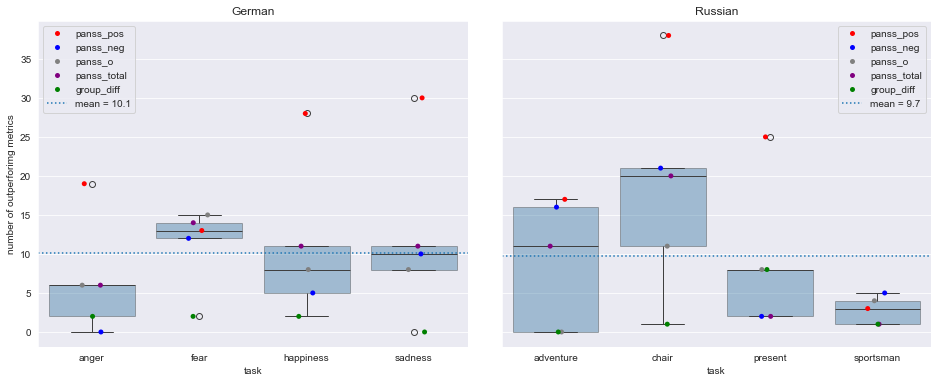

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plt.subplots_adjust(wspace=0.08)
for i, lang in enumerate(["de", "ru"]):
    ax = axes[i]
    data = boxplot_df[boxplot_df["lang"] == lang]
    mean = boxplot_df.groupby("lang")["outperform_count"].mean()[lang]
    sns.boxplot(ax=ax, data=data, x="task", y="outperform_count", boxprops={'alpha': 0.4})
    sns.stripplot(ax=ax, data=data, x="task", y="outperform_count", hue="scale", palette=sc_to_c)
    ax.axhline(mean, linestyle=':', label=f"mean = {mean}")
    ax.set_title(f"Russian" if lang == "ru" else "German")
    if i == 0:
        ax.set_ylabel("number of outperforimg metrics")
    ax.legend()

In [130]:
# fig, ax = plt.subplots(1, 1, figsize=(12, 8))
# ax = sns.boxplot(data=boxplot_df, x="task", y="outperform_count", boxprops={'alpha': 0.4}, hue="lang")
# sns.stripplot(data=boxplot_df, x="task", y="outperform_count", color="gray")
# # handles, labels = ax.get_legend_handles_labels()

## Particle use

In [131]:
from collections import Counter

In [132]:
all_part_ru = set()
all_part_de = set()
data = {'lang': [], 'task': [], 'id': [], 'line_counts': []}
with open('/Users/galina.ryazanskaya/Downloads/thesis?/code?/processed_values/part.tsv') as f:
    for line in f.readlines():
        line_counts = Counter()
        line = line.strip()
        els = line.split('\t')
        id_ = els[0]
        task_ = els[1]
        lang_ = 'de' if ("NET" in id_ or 'manual' in id_) else 'ru'
        set_ = all_part_de if lang_ == 'de' else all_part_ru
        for i in range(2, len(els[2:]), 2):
            if i + 1 < len(els[1:]):
                key, value = els[i], els[i+1]
                if key not in set_:
                    set_.add(key.lower())
                line_counts[key.lower()] += int(value)
        data['lang'].append(lang_)
        data['task'].append(task_)
        data['id'].append(id_)
        data['line_counts'].append(line_counts)

In [133]:
data_df = data.copy()
del data_df['line_counts']
iddf = pd.DataFrame.from_dict(data_df)

In [134]:
part_data = {}
for el in sorted(all_part_de | all_part_ru):
    part_data[el] = []
    for line in data['line_counts']:
        part_data[el].append(line[el])

In [135]:
part_df = pd.concat([iddf, pd.DataFrame.from_dict(part_data).astype(float)], axis=1)

In [136]:
ru = part_df[part_df['lang'] == 'ru'].sum(axis=0, numeric_only=True)
ru = ru[ru > 0]
print(ru.sort_values(ascending=False))

вот         815.0
не          812.0
ну          479.0
же          230.0
и           193.0
да          153.0
даже        124.0
просто       69.0
все          42.0
ли           37.0
именно       33.0
-            28.0
ни           26.0
бы           25.0
ладно        23.0
будто        16.0
всего        14.0
нет          13.0
ведь          9.0
таки          8.0
только        8.0
а             6.0
ж             5.0
ой            4.0
еле           4.0
ка            4.0
лишь          3.0
че            3.0
вон           3.0
неужели       2.0
пусть         2.0
аж            2.0
н             1.0
напросто      1.0
жил           1.0
едва          1.0
господи       1.0
варя          1.0
блин          1.0
ай            1.0
уж            1.0
звать         1.0
dtype: float64


In [137]:
de = part_df[part_df['lang'] == 'de'].sum(axis=0, numeric_only=True)
de = de[de > 0]
print(de.sort_values(ascending=False))

nicht    1651.0
ja        824.0
nein       49.0
am         28.0
naja       14.0
zu         11.0
ach         2.0
ah          2.0
na          2.0
dtype: float64


## Result tables

In [138]:
ex = long_df[(long_df['lang'] == 'ru') & (long_df['task'] == 'adventure')][['metric_group', 'metric_name', 'scale', 'median', 'CI_low', 'CI_high']]

In [139]:
metric_to_group = {}
for mn in ex['metric_name'].unique():
    metric_to_group[mn] =  ex[ex['metric_name'] == mn]['metric_group'].iloc[0]

In [140]:
with pd.ExcelWriter('result_values.xlsx') as writer:
    for lang in ['ru', 'de']:
        for task in long_df[long_df['lang'] == lang]['task'].unique():
            ex = long_df[(long_df['lang'] == lang) & (long_df['task'] == task)][['metric_group', 'metric_name', 'scale', 'median', 'CI_low', 'CI_high']]
            pivot = ex.pivot(index='metric_name', columns='scale', values=['median','CI_low','CI_high']).swaplevel(axis=1).sort_index(axis=1, level=0, ascending=False)
            pivot['metric_group'] = pivot.index.map(lambda x: metric_to_group.get(x))
            pivot = pivot.set_index('metric_group', append=True).reorder_levels(['metric_group', 'metric_name'])
            pivot = pivot.sort_index(axis=0, level=1, ascending=False).sort_index(axis=0, level=0, ascending=False)        
            pivot.to_excel(writer, sheet_name=f'{lang} {task}')  
    
    for lang in ['ru', 'de']:
        for task in long_df[long_df['lang'] == lang]['task'].unique():
            ex_corr = long_df[(long_df['lang'] == lang) & (long_df['task'] == task) & (long_df['scale'] == "panss_total")][
                ['metric_group', 'metric_name', 'corr_mean_sent_len_median', 'corr_mean_sent_len_mean',
                 'corr_mean_sent_len_CI_low', 'corr_mean_sent_len_CI_high',
                 'corr_n_sents_median', 'corr_n_sents_mean', 'corr_n_sents_CI_low',
                 'corr_n_sents_CI_high', 'corr_n_words_median', 'corr_n_words_mean',
                 'corr_n_words_CI_low', 'corr_n_words_CI_high']
            ]
            ex_corr = ex_corr.set_index(['metric_group', 'metric_name'])
            ex_corr = ex_corr.sort_index(axis=0, level=1, ascending=False).sort_index(axis=0, level=0, ascending=False)        
            ex_corr.to_excel(writer, sheet_name=f'{lang} {task} corr verbosity')  

In [141]:
raw_means_ru = pd.read_csv('feature_means_ru.csv').set_index(['task', 'feature_group', 'feature']).sort_index(axis=0, level=0, ascending=False)
raw_means_de = pd.read_csv('feature_means_de.csv').set_index(['task', 'feature_group', 'feature']).sort_index(axis=0, level=0, ascending=False)

In [142]:
with pd.ExcelWriter('raw_sample_means.xlsx') as writer:
    raw_means_de.to_excel(writer, sheet_name=f'de')
    raw_means_ru.to_excel(writer, sheet_name=f'ru')